# DSMarket - Tarea 3: Predicción de ventas

El objetivo de este notebook es realizar predicciones de ventas para las 4 semanas siguientes a la última semana completa.

Se ha decidido comenzar desde la importación de datos ya que la predicción tiene carácter semanal y se van a realizar preprocesados diferentes al Notebook 01.

## 1. Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder

import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

## 2. Paths and directories

In [2]:
sales_data_path = r"data\item_sales.csv"
calendar_data_path = r"data\daily_calendar_with_events.csv"
prices_data_path = r"data\item_prices.csv"

## 3. Import files

### 3.1. Ventas

El df de ventas tiene los datos de ventas por día, organizado de forma que cada día tiene su columna. Vamos a tener que hacer una transformación para que los días formen parte de una sola columna, para poder agruparlos por semanas y que el 'pd_sales' se pueda unir con las demás tablas.  

In [3]:
pd_sales = pd.read_csv(sales_data_path, sep = ",")
print("La forma del dataframe de ventas es:", pd_sales.shape)

La forma del dataframe de ventas es: (30490, 1920)


In [4]:
pd_sales.head()

,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,2,0,2,2,0,0,0,1,1,0,2,0,1,1,2,0,1,0,0,0,2,1,0,1,1,2,0,0,0,0,0,0,0,1,0,1,0,1,0,3,1,1,0,1,1,2,0,0,0,0,1,1,0,0,0,0,3,0,1,0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,2,0,0,0,0,1,1,2,0,0,0,0,2,0,0,1,1,1,1,0,0,0,0,0,1,2,2,0,1,0,0,0,0,1,2,1,0,0,0,0,0,1,0,3,0,1,2,1,0,3,

In [5]:
pd_sales.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Data columns (total 1920 columns):
 #     Column      Dtype
---    ------      -----
 0     id          str  
 1     item        str  
 2     category    str  
 3     department  str  
 4     store       str  
 5     store_code  str  
 6     region      str  
 7     d_1         int64
 8     d_2         int64
 9     d_3         int64
 10    d_4         int64
 11    d_5         int64
 12    d_6         int64
 13    d_7         int64
 14    d_8         int64
 15    d_9         int64
 16    d_10        int64
 17    d_11        int64
 18    d_12        int64
 19    d_13        int64
 20    d_14        int64
 21    d_15        int64
 22    d_16        int64
 23    d_17        int64
 24    d_18        int64
 25    d_19        int64
 26    d_20        int64
 27    d_21        int64
 28    d_22        int64
 29    d_23        int64
 30    d_24        int64
 31    d_25        int64
 32    d_26        int64
 33    d_27        int64


### 3.2. Calendario
'pd_calendar' tiene un día por fila y una columna 'event' que indica si hay evento (indica nombre) o no (valor nulo). Deberemos añadir una columna que indique la semana del año para poder unirla a las demás tablas.

In [6]:
pd_calendar = pd.read_csv(calendar_data_path, sep = ",")
print("La forma del dataframe de calendario es:", pd_calendar.shape)

La forma del dataframe de calendario es: (1913, 5)


In [7]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN


In [8]:
pd_calendar.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         1913 non-null   str  
 1   weekday      1913 non-null   str  
 2   weekday_int  1913 non-null   int64
 3   d            1913 non-null   str  
 4   event        26 non-null     str  
dtypes: int64(1), str(4)
memory usage: 117.5 KB


In [9]:
print("El rango de fechas disponibles es: {} - {}".format(pd_calendar['date'].min(),pd_calendar['date'].max()))

El rango de fechas disponibles es: 2011-01-29 - 2016-04-24


Qué eventos tenemos?

In [10]:
pd_calendar.event.value_counts(dropna=False)

event
NaN               1887
SuperBowl            6
Ramadan starts       5
Thanksgiving         5
NewYear              5
Easter               5
Name: count, dtype: int64

### 3.3. Precios

- Esta tabla sí que está organizada de manera semanal. Como se puede apreciar hay varios valores por item, por lo que el precio puede variar por tienda y durante el tiempo.
- Tiene valores nulos en la columna 'yearweek', por lo que los precios no se podrían localizar en el tiempo. Se decide eliminar estos registros, pero si hubiese más input de datos con el mismo problema, habría que ver qué causa el valor nulo.

In [11]:
pd_prices = pd.read_csv(prices_data_path, sep = ",")
print("La forma del dataframe de precios es:", pd_prices.shape)

La forma del dataframe de precios es: (6965706, 5)


In [12]:
pd_prices.head()

,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,328.00",12.74
1,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,329.00",12.74
2,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,330.00",10.99
3,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,331.00",10.99
4,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,332.00",10.99


In [13]:
pd_prices.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 6965706 entries, 0 to 6965705
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        str    
 1   category    str    
 2   store_code  str    
 3   yearweek    float64
 4   sell_price  float64
dtypes: float64(2), str(3)
memory usage: 491.7 MB


In [14]:
print("There are {} items in the data, and the number of registers per item are: ".format(pd_prices.item.nunique()))
pd_prices.item.value_counts()

There are 3049 items in the data, and the number of registers per item are: 


item
ACCESORIES_1_010       2870
ACCESORIES_1_022       2870
ACCESORIES_1_023       2870
ACCESORIES_1_028       2870
ACCESORIES_1_032       2870
                       ... 
HOME_&_GARDEN_1_308     652
HOME_&_GARDEN_1_159     633
HOME_&_GARDEN_1_242     610
SUPERMARKET_3_296       602
SUPERMARKET_2_379       543
Name: count, Length: 3049, dtype: int64

Let's take a loook at the variables distribution of the prices dataframe

In [15]:
pd_prices.describe()

,yearweek,sell_price
count,"6,721,786.00","6,965,706.00"
mean,"201,382.42",5.52
std,145.02,4.39
min,"201,105.00",0.01
25%,"201,248.00",2.62
50%,"201,410.00",4.20
75%,"201,515.00",7.18
max,"201,617.00",134.15


In [16]:
pd_prices.describe(include=['object'])

,item,category,store_code
count,6965706,6965706,6965706
unique,3049,3,10
top,ACCESORIES_1_010,SUPERMARKET,BOS_2
freq,2870,3239821,713960


In [17]:
pd_prices.yearweek.isnull().sum()/pd_prices.shape[0]

np.float64(0.03501726888846586)

In [18]:
pd_prices.loc[pd_prices['yearweek'].isnull()]

,item,category,store_code,yearweek,sell_price
149,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
150,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
151,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
152,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
153,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.15
...,...,...,...,...,...
6965701,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965702,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965703,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20
6965704,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.20


Se eliminan los nulos en'yearweek' (3.5%) y se pasa 'yearweek' a int para poder unirla a las demás tablas 

In [19]:
pd_prices = pd_prices.dropna(subset=['yearweek'])
pd_prices['yearweek'] = pd_prices['yearweek'].astype(int)

In [20]:
pd_prices.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 6721786 entries, 0 to 6965697
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        str    
 1   category    str    
 2   store_code  str    
 3   yearweek    int64  
 4   sell_price  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 528.1 MB


In [21]:
pd_prices['sell_price'].isnull().sum()/pd_prices.shape[0]

np.float64(0.0)

In [22]:
pd_prices.reset_index(drop=True, inplace=True)

Por último se ordena el dataset de precios para que se pueda unir correctamente más adelante

In [23]:
pd_prices_sorted = pd_prices.sort_values(by=['item', 'store_code','yearweek']).reset_index(drop=True)

### 3.4. Clusters
Se podría unir la columna 'cluster' de 'pd_clusters' con el 'pd_prices_sorted' por 'item' para añadir esta info de cara a la predicción. Idealmente no debería emplearse esta columna para el entrenamiento del modelo, ya que los clusters se han aprendido de el dataset completo y podría producirse leakage.
También se podría fijar el entrenamiento de clusters con el dataset de train y de esta manera emplear los clusters en la predicción, con alguna prueba no mejoraba la predicción, es por esto que se ha decidido dejar a parte.

In [25]:
# pd_clusters = pd.read_csv(r"data\clusters.csv", sep = ",")
# pd_prices_clusters = pd_prices_sorted.merge(pd_clusters[['item', 'cluster']], on=['item'], how='left')

## 4. Gestión de tablas para poder unirlas en 1 sólo dataset

### 4.1. Calendar

Primero se crea la columna 'yearweek' para poder juntarla con las demás tablas. El día 1 de la semana corresponde al sábado y el 7 al viernes.

In [26]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN


In [27]:
from datetime import datetime, timedelta
def weekyearnum(dt):
    return dt.strftime("%Y%W")

def myweekyearnum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weekyearnum(offsetdt)

def weeknum(dt):
    return dt.isocalendar()[1]

def myweeknum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weeknum(offsetdt)

In [28]:
## Merge
pd_calendar['date'] = pd.to_datetime(pd_calendar['date'], format = "%Y-%m-%d")

pd_calendar['yearweek'] = pd_calendar['date'].apply(lambda x: myweekyearnum(x)).astype(int)

In [29]:
pd_calendar.loc[pd_calendar['event']=="Ramadan starts"]

,date,weekday,weekday_int,d,event,yearweek
184,2011-08-01,Monday,3,d_185,Ramadan starts,201131
538,2012-07-20,Friday,7,d_539,Ramadan starts,201229
892,2013-07-09,Tuesday,4,d_893,Ramadan starts,201327
1247,2014-06-29,Sunday,2,d_1248,Ramadan starts,201426
1601,2015-06-18,Thursday,6,d_1602,Ramadan starts,201524


#### Adición de la columna 'is_Ramadan' y los eventos 'Christmas' e 'Independence Day'

In [30]:
pd_calendar.loc[(pd_calendar['date'].dt.day == 25) & (pd_calendar['date'].dt.month == 12), 'event'] = "Christmas"

In [31]:
pd_calendar.loc[(pd_calendar['date'].dt.day == 4) & (pd_calendar['date'].dt.month == 7), 'event'] = "Independence_Day"

In [32]:
pd_calendar['is_Ramadan'] = 0

ramadan_starts = pd_calendar.loc[pd_calendar['event'] == 'Ramadan starts', 'date']

for start_date in ramadan_starts:
    mask = (pd_calendar['date'] >= start_date) & (pd_calendar['date'] < start_date + pd.Timedelta(days=30))
    
    pd_calendar.loc[
        mask,
        'is_Ramadan'
    ] = 1

In [33]:
pd_calendar.rename(columns={'d': 'day'}, inplace=True)

In [34]:
pd_calendar['is_Event'] = pd_calendar['event'].notnull()

#### Weekly Calendar

Aquí se crea la tabla calendario en formato semanal
- Se tiene en cuenta cuántos días de evento o ramadan hay en la semana
- Los eventos se recogen de forma que hay una columna con el nombre del primer evento de la semana en 'first_event' y se guarda el día de la semana del evento en la columna 'first_event_dow'


In [35]:
pd_calendar = pd_calendar.sort_values(['yearweek', 'date'])
weekly_calendar = (
    pd_calendar
    .groupby('yearweek')
    .agg(
        event_count=('is_Event', 'sum'),
        ramadan_count=('is_Ramadan', 'sum'),

        # First non-null event, otherwise 'NoEvent'
        first_event=('event', lambda x: x.dropna().iloc[0] 
                     if x.notna().any() else 'NoEvent'),

        # Day of week of first non-null event, else -1
        first_event_dow=('event', lambda x: 
            pd_calendar.loc[x.dropna().index[0], 'weekday_int']
            if x.notna().any() else -1),

        # Event on weekend (same logic, but safe)
        event_on_weekend=('weekday_int', lambda x: int(
            any(
                (pd_calendar.loc[x.index, 'weekday_int'] <= 2) & 
                (pd_calendar.loc[x.index, 'is_Event'] == 1)
            )
        ))
    )
    .reset_index()
)

### 4.2 Ventas

- Primero se deben pasar el formato de 1 día por columna a una columna con todos los días.
- Posteriormente se agruparán los datos de forma semanal

In [36]:
pd_sales.set_index(['id','item','category','department','store','store_code','region']).head()

,,,,,,,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,d_95,d_96,d_97,d_98,d_99,d_100,d_101,d_102,d_103,d_104,d_105,d_106,d_107,d_108,d_109,d_110,d_111,d_112,d_113,d_114,d_115,d_116,d_117,d_118,d_119,d_120,d_121,d_122,d_123,d_124,d_125,d_126,d_127,d_128,d_129,d_130,d_131,d_132,d_133,d_134,d_135,d_136,d_137,d_138,d_139,d_140,d_141,d_142,d_143,d_144,d_145,d_146,d_147,d_148,d_149,d_150,d_151,d_152,d_153,d_154,d_155,d_156,d_157,d_158,d_159,d_160,d_161,d_162,d_163,d_164,d_165,d_166,d_167,d_168,d_169,d_170,d_171,d_172,d_173,d_174,d_175,d_176,d_177,d_178,d_179,d_180,d_181,d_182,d_183,d_184,d_185,d_186,d_187,d_188,d_189,d_190,d_191,d_192,d_193,d_194,d_195,d_196,d_197,d_198,d_199,d_200,d_201,d_202,d_203,d_204,d_205,d_206,d_207,d_208,d_209,d_210,d_211,d_212,d_213,d_214,d_215,d_216,d_217,d_218,d_219,d_220,d_221,d_222,d_223,d_224,d_225,d_226,d_227,d_228,d_229,d_230,d_231,d_232,d_233,d_234,d_235,d_236,d_237,d_238,d_239,d_240,d_241,d_242,d_243,d_244,d_245,d_246,d_247,d_248,d_249,d_250,...,d_1664,d_1665,d_1666,d_1667,d_1668,d_1669,d_1670,d_1671,d_1672,d_1673,d_1674,d_1675,d_1676,d_1677,d_1678,d_1679,d_1680,d_1681,d_1682,d_1683,d_1684,d_1685,d_1686,d_1687,d_1688,d_1689,d_1690,d_1691,d_1692,d_1693,d_1694,d_1695,d_1696,d_1697,d_1698,d_1699,d_1700,d_1701,d_1702,d_1703,d_1704,d_1705,d_1706,d_1707,d_1708,d_1709,d_1710,d_1711,d_1712,d_1713,d_1714,d_1715,d_1716,d_1717,d_1718,d_1719,d_1720,d_1721,d_1722,d_1723,d_1724,d_1725,d_1726,d_1727,d_1728,d_1729,d_1730,d_1731,d_1732,d_1733,d_1734,d_1735,d_1736,d_1737,d_1738,d_1739,d_1740,d_1741,d_1742,d_1743,d_1744,d_1745,d_1746,d_1747,d_1748,d_1749,d_1750,d_1751,d_1752,d_1753,d_1754,d_1755,d_1756,d_1757,d_1758,d_1759,d_1760,d_1761,d_1762,d_1763,d_1764,d_1765,d_1766,d_1767,d_1768,d_1769,d_1770,d_1771,d_1772,d_1773,d_1774,d_1775,d_1776,d_1777,d_1778,d_1779,d_1780,d_1781,d_1782,d_1783,d_1784,d_1785,d_1786,d_1787,d_1788,d_1789,d_1790,d_1791,d_1792,d_1793,d_1794,d_1795,d_1796,d_1797,d_1798,d_1799,d_1800,d_1801,d_1802,d_1803,d_1804,d_1805,d_1806,d_1807,d_1808,d_1809,d_1810,d_1811,d_1812,d_1813,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
id,item,category,department,store,store_code,region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [37]:
for c in pd_sales.columns:
    if pd_sales[c].dtype == 'object':
        pd_sales[c] = pd_sales[c].astype('category')

In [38]:
pd_sales_long = pd_sales.melt(
    id_vars=['id','item','category','department','store','store_code','region'],
    var_name='day',
    value_name='sales'
)

In [39]:
pd_sales_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 9 columns):
 #   Column      Dtype
---  ------      -----
 0   id          str  
 1   item        str  
 2   category    str  
 3   department  str  
 4   store       str  
 5   store_code  str  
 6   region      str  
 7   day         str  
 8   sales       int64
dtypes: int64(1), str(8)
memory usage: 9.1 GB


In [40]:
pd_sales_long.loc[pd_sales_long['id'] == 'ACCESORIES_1_005_NYC_1']

,id,item,category,department,store,store_code,region,day,sales
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
30494,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_2,0
60984,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_3,0
91474,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_4,0
121964,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_5,0
...,...,...,...,...,...,...,...,...,...
58174924,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1909,1
58205414,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1910,2
58235904,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1911,2
58266394,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1912,2


#### 4.2.1. Ventas semanales

In [41]:
pd_sales_long = pd_sales_long.merge(
    pd_calendar[['day', 'date', 'yearweek']],
    left_on='day',
    right_on='day',
    how='left'
)

In [42]:
pd_sales_long_weekly = (
    pd_sales_long
    .groupby(['item', 'store','yearweek'])
    .agg({
        'category': 'first',
        'department': 'first',
        'region': 'first',
        'sales': 'sum',
        'store_code': 'first'
    })
    .reset_index()
)

In [43]:
pd_sales_long_weekly

,item,store,yearweek,category,department,region,sales,store_code
0,ACCESORIES_1_001,Back_Bay,201105,ACCESORIES,ACCESORIES_1,Boston,0,BOS_3
1,ACCESORIES_1_001,Back_Bay,201106,ACCESORIES,ACCESORIES_1,Boston,0,BOS_3
2,ACCESORIES_1_001,Back_Bay,201107,ACCESORIES,ACCESORIES_1,Boston,0,BOS_3
3,ACCESORIES_1_001,Back_Bay,201108,ACCESORIES,ACCESORIES_1,Boston,0,BOS_3
4,ACCESORIES_1_001,Back_Bay,201109,ACCESORIES,ACCESORIES_1,Boston,0,BOS_3
...,...,...,...,...,...,...,...,...
8506705,SUPERMARKET_3_827,Yorktown,201613,SUPERMARKET,SUPERMARKET_3,Philadelphia,24,PHI_2
8506706,SUPERMARKET_3_827,Yorktown,201614,SUPERMARKET,SUPERMARKET_3,Philadelphia,21,PHI_2
8506707,SUPERMARKET_3_827,Yorktown,201615,SUPERMARKET,SUPERMARKET_3,Philadelphia,25,PHI_2
8506708,SUPERMARKET_3_827,Yorktown,201616,SUPERMARKET,SUPERMARKET_3,Philadelphia,13,PHI_2


### 4.3. Unión de tablas en 'df_dsMarket_weekly'

In [44]:
df_dsMarket_weekly = pd_sales_long_weekly.merge(
    weekly_calendar[['yearweek', 'event_count', 'ramadan_count', 'first_event', 'first_event_dow', 'event_on_weekend']],
    on='yearweek',
    how='left'
)

In [45]:
df_dsMarket_weekly = df_dsMarket_weekly.merge(
    pd_prices_sorted[['item','yearweek', 'sell_price', 'store_code']],
    on=['item', 'store_code', 'yearweek'],
    how='inner'
)

In [46]:
# Calculo de ingresos
df_dsMarket_weekly['revenue'] = df_dsMarket_weekly['sales'] * df_dsMarket_weekly['sell_price']

In [47]:
df_dsMarket_weekly.info()

<class 'pandas.DataFrame'>
RangeIndex: 6721786 entries, 0 to 6721785
Data columns (total 15 columns):
 #   Column            Dtype  
---  ------            -----  
 0   item              str    
 1   store             str    
 2   yearweek          int64  
 3   category          str    
 4   department        str    
 5   region            str    
 6   sales             int64  
 7   store_code        str    
 8   event_count       int64  
 9   ramadan_count     int64  
 10  first_event       str    
 11  first_event_dow   int64  
 12  event_on_weekend  int64  
 13  sell_price        float64
 14  revenue           float64
dtypes: float64(2), int64(6), str(7)
memory usage: 1.2 GB


In [49]:
df_dsMarket_weekly = df_dsMarket_weekly.astype({
    "item": "category",
    "store": "category",
    "yearweek": "int32",
    "sales": "int32",
    "event_count": "int8",
    "ramadan_count": "int8",
    "first_event": "category",
    "first_event_dow": "int8",
    "event_on_weekend": "int8",
    "sell_price": "float32",
    #"cluster": "category",
    "revenue": "float32"
})

In [50]:
df_dsMarket_weekly.info()

<class 'pandas.DataFrame'>
RangeIndex: 6721786 entries, 0 to 6721785
Data columns (total 15 columns):
 #   Column            Dtype   
---  ------            -----   
 0   item              category
 1   store             category
 2   yearweek          int32   
 3   category          str     
 4   department        str     
 5   region            str     
 6   sales             int32   
 7   store_code        str     
 8   event_count       int8    
 9   ramadan_count     int8    
 10  first_event       category
 11  first_event_dow   int8    
 12  event_on_weekend  int8    
 13  sell_price        float32 
 14  revenue           float32 
dtypes: category(3), float32(2), int32(2), int8(4), str(4)
memory usage: 609.7 MB


In [51]:
df_dsMarket_weekly.isnull().sum()

item                0
store               0
yearweek            0
category            0
department          0
region              0
sales               0
store_code          0
event_count         0
ramadan_count       0
first_event         0
first_event_dow     0
event_on_weekend    0
sell_price          0
revenue             0
dtype: int64

In [52]:
df_dsMarket_weekly.sort_values(by=['item', 'store','yearweek'], inplace=True)

In [53]:
df_dsMarket_weekly.head(20)

,item,store,yearweek,category,department,region,sales,store_code,event_count,ramadan_count,first_event,first_event_dow,event_on_weekend,sell_price,revenue
0,ACCESORIES_1_001,Back_Bay,201330,ACCESORIES,ACCESORIES_1,Boston,1,BOS_3,0,7,NoEvent,-1,0,11.46,11.46
1,ACCESORIES_1_001,Back_Bay,201331,ACCESORIES,ACCESORIES_1,Boston,3,BOS_3,0,5,NoEvent,-1,0,11.46,34.39
2,ACCESORIES_1_001,Back_Bay,201332,ACCESORIES,ACCESORIES_1,Boston,1,BOS_3,0,0,NoEvent,-1,0,11.46,11.46
3,ACCESORIES_1_001,Back_Bay,201333,ACCESORIES,ACCESORIES_1,Boston,1,BOS_3,0,0,NoEvent,-1,0,11.46,11.46
4,ACCESORIES_1_001,Back_Bay,201334,ACCESORIES,ACCESORIES_1,Boston,3,BOS_3,0,0,NoEvent,-1,0,11.46,34.39
5,ACCESORIES_1_001,Back_Bay,201335,ACCESORIES,ACCESORIES_1,Boston,2,BOS_3,0,0,NoEvent,-1,0,11.46,22.93
6,ACCESORIES_1_001,Back_Bay,201336,ACCESORIES,ACCESORIES_1,Boston,3,BOS_3,0,0,NoEvent,-1,0,11.46,34.39
7,ACCESORIES_1_001,Back_Bay,201337,ACCESORIES,ACCESORIES_1,Boston,4,BOS_3,0,0,NoEvent,-1,0,11.46,45.86
8,ACCESORIES_1_001,Back_Bay,201338,ACCESORIES,ACCESORIES_1,Boston,2,BOS_3,0,0,NoEvent,-1,0,11.46,22.93
9,ACCESORIES_1_001,Back_Bay,201339,ACCESORIES,ACCESORIES_1,Boston,1,BOS_3,0,0,NoEvent,-1,0,11.46,11.46


Por último, retiramos los datos de la última semana ya que no está completa y nos aportaría ruido y datos incompletos.

In [54]:
df_dsMarket_weekly['yearweek'].max()

np.int32(201617)

In [55]:
df_dsMarket_weekly = df_dsMarket_weekly.loc[df_dsMarket_weekly['yearweek'] < df_dsMarket_weekly['yearweek'].max()]

## 5. Algoritmos XGBoost y Light GBM

In [56]:
df_dsMarket_weekly

,item,store,yearweek,category,department,region,sales,store_code,event_count,ramadan_count,first_event,first_event_dow,event_on_weekend,sell_price,revenue
0,ACCESORIES_1_001,Back_Bay,201330,ACCESORIES,ACCESORIES_1,Boston,1,BOS_3,0,7,NoEvent,-1,0,11.46,11.46
1,ACCESORIES_1_001,Back_Bay,201331,ACCESORIES,ACCESORIES_1,Boston,3,BOS_3,0,5,NoEvent,-1,0,11.46,34.39
2,ACCESORIES_1_001,Back_Bay,201332,ACCESORIES,ACCESORIES_1,Boston,1,BOS_3,0,0,NoEvent,-1,0,11.46,11.46
3,ACCESORIES_1_001,Back_Bay,201333,ACCESORIES,ACCESORIES_1,Boston,1,BOS_3,0,0,NoEvent,-1,0,11.46,11.46
4,ACCESORIES_1_001,Back_Bay,201334,ACCESORIES,ACCESORIES_1,Boston,3,BOS_3,0,0,NoEvent,-1,0,11.46,34.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6721780,SUPERMARKET_3_827,Yorktown,201612,SUPERMARKET,SUPERMARKET_3,Philadelphia,7,PHI_2,0,0,NoEvent,-1,0,1.20,8.40
6721781,SUPERMARKET_3_827,Yorktown,201613,SUPERMARKET,SUPERMARKET_3,Philadelphia,24,PHI_2,1,0,Easter,2,1,1.20,28.80
6721782,SUPERMARKET_3_827,Yorktown,201614,SUPERMARKET,SUPERMARKET_3,Philadelphia,21,PHI_2,0,0,NoEvent,-1,0,1.20,25.20
6721783,SUPERMARKET_3_827,Yorktown,201615,SUPERMARKET,SUPERMARKET_3,Philadelphia,25,PHI_2,0,0,NoEvent,-1,0,1.20,30.00


### 5.1. Configuración de training y adición de features (lag y rolling)

In [ ]:
# ── config ────────────────────────────────────────────────────────────────────
TARGET       = "sales"
GROUP_COLS   = ["store", "item"]
YEARWEEK_COL = "yearweek"          # integer YYYYWW

# Columns to DROP entirely (pure identifiers / redundant)
DROP_COLS = ['id', 'day', 'store_code', "store_id", 'start_date', 'revenue', 'cluster']  

# Categoricals that need encoding (first_event is also categorical)
CAT_COLS = ["item", "store", "category", "department", "region", "first_event"]

# Lag distances and rolling windows — in weeks
WEEKLY_LAG_WEEKS    = [1, 2, 4, 8]    # ~1w, 2w, 1m, 2m
WEEKLY_ROLL_WINDOWS = [4, 8, 13]      # ~1m, 2m, quarter

TRAIN_RATIO = 0.8

# ─────────────────────────────────────────────
# 1. Eliminador de redundancias. En vistas a evitar leakage que se produciría con la inclusión de columnas calculadas del Target como revenue
# ─────────────────────────────────────────────
def drop_redundant(df: pd.DataFrame) -> pd.DataFrame:
    existing = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=existing)
    print(f"Dropped redundant columns: {existing}")
    return df

# ── 1. Columna 'yearweek' → features ────────────────────────────────────────

def add_weekly_date_features(df: pd.DataFrame) -> pd.DataFrame:

    yw = df[YEARWEEK_COL].astype(str).str.zfill(6)

    year = yw.str[:4].astype(int)
    week = yw.str[4:].astype(int)

    # Fix invalid week 00 → treat as week 1 (or shift to last week prev year if you prefer)
    week = week.replace(0, 1)

    # Build a base date: Jan 1 of each year
    base_date = pd.to_datetime(year.astype(str) + "-01-01")

    # Since your weeks start on Saturday:
    # We shift to the first Saturday of the year, then add weeks
    first_saturday = base_date + pd.to_timedelta((5 - base_date.dt.weekday) % 7, unit="D")

    week_start = first_saturday + pd.to_timedelta((week - 1) * 7, unit="D")

    #df["week_of_year"]   = yw.str[4:].astype(int)     # Se decide emplear el día del año en lugar del número de semana para evitar casos límites en transiciones de año
    df["year"]           = yw.str[:4].astype(int)
    df["month"]          = week_start.dt.month
    df["quarter"]        = week_start.dt.quarter
    df["is_month_start"] = (week_start.dt.day <= 7).astype(int)   # True in first week of month
    df["is_salary_week"] = week_start.dt.day.between(7, 15).astype(int)
    df["day_of_year"] = week_start.dt.dayofyear

    # Drop the raw yearweek — the integer itself is not meaningful to the tree
    #df = df.drop(columns=[YEARWEEK_COL])
    print(f"Parsed {YEARWEEK_COL} → day_of_year, year, month, quarter, is_month_start. ")
          #f"Dropped {YEARWEEK_COL}.")
    return df


# ── 2. Limpiado de las columnas de eventos, por si viniese algún nulo ────────────────────────────────────────────────────

def clean_event_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Estandarización de las columnas de eventos.
    """
    df["first_event"]      = df["first_event"].fillna("NoEvent")
    df["first_event_dow"]  = df["first_event_dow"].fillna(-1).astype(int)
    df["event_on_weekend"] = df["event_on_weekend"].fillna(0).astype(int)
    df["event_count"]      = df["event_count"].fillna(0).astype(int)
    df["ramadan_count"]    = df["ramadan_count"].fillna(0).astype(int)

    # Binary convenience flag — strong signal for the model
    df["has_event"] = (df["event_count"] > 0).astype(int)

    print(f"Event columns cleaned. "
          f"Weeks with ≥1 event: {df['has_event'].sum():,} / {len(df):,}  "
          f"| Ramadan weeks: {(df['ramadan_count'] > 0).sum():,}")
    return df


# ── 3. Encoder de categóricas ────────────────────────────────────────────────────

def encode_categoricals(df: pd.DataFrame):
    
    existing = [c for c in CAT_COLS if c in df.columns]

    X_cat = df[existing]

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    encoded = enc.fit_transform(X_cat).astype(int)

    # se mantienen las columnas originales
    df_raw = df.copy()

    # adición de columnas codificadas con sufijo _enc
    for i, col in enumerate(existing):
        df[col + "_enc"] = encoded[:, i]

    return df, df_raw, enc


# ── 4. Lag features ───────────────────────────────────────────────────────────

def add_weekly_lag_features(df: pd.DataFrame, GROUP_COLS = GROUP_COLS) -> pd.DataFrame:
    """Shift sales back N weeks per store × item_id group."""
    grp = df.groupby(GROUP_COLS)[TARGET]
    for lag in WEEKLY_LAG_WEEKS:
        df[f"lag_{lag}w"] = grp.shift(lag)
    print(f"Added lag features: {[f'lag_{l}w' for l in WEEKLY_LAG_WEEKS]}")
    return df


# ── 5. Rolling features ───────────────────────────────────────────────────────

def add_weekly_rolling_features(df: pd.DataFrame, GROUP_COLS = GROUP_COLS) -> pd.DataFrame:
    """
    Rolling mean and std over the past N weeks (shift(1) prevents leakage).
    Computed per store_code × item_id group.
    """
    for w in WEEKLY_ROLL_WINDOWS:
        shifted = df.groupby(GROUP_COLS)[TARGET].shift(1)
        df[f"roll_mean_{w}w"] = (
            shifted.groupby([df[c] for c in GROUP_COLS])
                   .transform(lambda x: x.rolling(w, min_periods=1).mean())
        )
        df[f"roll_std_{w}w"] = (
            shifted.groupby([df[c] for c in GROUP_COLS])
                   .transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
        )
    print(f"Added rolling mean/std for windows: {WEEKLY_ROLL_WINDOWS} weeks")
    return df


# ── 6. Validation ─────────────────────────────────────────────────────────────

def validate_weekly_df(df: pd.DataFrame, min_weeks: int = 10, drop_sparse: bool = False, GROUP_COLS = GROUP_COLS):
    """Sanity checks and optional removal of sparse groups."""

    print(f"\n── Weekly data validation ──")
    print(f"  Rows              : {len(df):,}")
    print(f"  Zero-sales weeks  : {(df[TARGET] == 0).mean():.1%}")
    print(f"  Sales range       : {df[TARGET].min():.0f} – {df[TARGET].max():.0f}")
    print(f"  Mean weekly sales : {df[TARGET].mean():.2f}")

    # --- group counts ---
    group_counts = df.groupby(GROUP_COLS).size()

    sparse_groups = group_counts[group_counts < min_weeks]

    if not sparse_groups.empty:
        print(f"\n⚠️ Found {len(sparse_groups)} groups with <{min_weeks} weeks")

        # print("\nSample sparse groups:")
        # print(sparse_groups.head(20))

        # optional: show full list if needed
        # print(sparse_groups.sort_values().to_string())

        if drop_sparse:
            valid_groups = group_counts[group_counts >= min_weeks].index

            df = df.set_index(GROUP_COLS)
            df = df.loc[valid_groups].reset_index()

            print(f"\n✅ Dropped sparse groups. New shape: {df.shape}")

    return df


# ─────────────────────────────────────────────
# 7. DROP NaN ROWS FROM LAG/ROLLING
# ─────────────────────────────────────────────
def drop_nan_rows(df: pd.DataFrame, GROUP_COLS = GROUP_COLS) -> pd.DataFrame:
    before = len(df)
    df = df.dropna().reset_index(drop=True)
    print(f"Dropped {before - len(df):,} NaN rows (from lag/rolling warmup). Remaining: {len(df):,}")
    return df


# ── 7. Full pipeline ──────────────────────────────────────────────────────────

def build_weekly_dataset(df: pd.DataFrame):
    """
    Load a pre-aggregated weekly CSV and run all feature engineering steps.

    Returns (model_ready_df, encoder) — feed directly into:
        temporal_split() → split_X_y() → train_xgboost() / train_lightgbm()
    """
    df = drop_redundant(df)

    # Critical: sort by time then group so lags are computed in the right order
    df = df.sort_values([YEARWEEK_COL] + GROUP_COLS).reset_index(drop=True)
    print(f"Loaded {len(df):,} rows | "
          f"yearweek {df[YEARWEEK_COL].min()} → {df[YEARWEEK_COL].max()}")

    df = add_weekly_date_features(df)    # YYYYWW → month, quarter, week_of_year, etc.
    df = clean_event_columns(df)         # fill NaNs, add has_event
    df, df_raw, encoder = encode_categoricals(df)
    df = add_weekly_lag_features(df)
    df = add_weekly_rolling_features(df)
    df = drop_nan_rows(df)               # remove warmup rows from lag creation

    df = validate_weekly_df(df, drop_sparse=False)
    return df, df_raw, encoder

### 5.2. Dataset split

1. Separamos cronológicamente el dataset en particiones que corresponden al Train_Ratio. En nuestro caso es 0.8, por lo que el 80% de las semanas, las más antiguas, formarán parte del train split.
2. Partición de X (features) e Y columna Target del dataset ('sales')

In [58]:
# ─────────────────────────────────────────────
# 8. SPLIT TEMPORAL
# ─────────────────────────────────────────────
def weekly_temporal_split(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    weeks = sorted(df[YEARWEEK_COL].unique())
    split_idx = int(len(weeks) * TRAIN_RATIO)
    split_week = weeks[split_idx]

    train = df[df[YEARWEEK_COL] < split_week].copy()
    test = df[df[YEARWEEK_COL] >= split_week].copy()

    print(f"Split week: {split_week}")
    print(f"Train: {len(train):,} rows | Test: {len(test):,} rows")

    return train, test


# ─────────────────────────────────────────────
# 9. FEATURE / TARGET SPLIT
# ─────────────────────────────────────────────
def split_X_y(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    existing = [c for c in CAT_COLS + [YEARWEEK_COL] if c in df.columns]
    X = df.drop(columns=[TARGET] + existing)  # keep encoded versions, drop raw categoricals
    y = df[TARGET]
    return X, y

### 5.3. Funciones de entrenamiento y evaluación de modelos

In [ ]:
# ─────────────────────────────────────────────
# EVALUACION PARA MODELOS DE VENTA SEMANALES
# ─────────────────────────────────────────────
def evaluate(y_true, y_pred, name: str):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    # Zero-sale accuracy: % of days where both actual and predicted are 0
    zero_acc = np.mean((y_true == 0) & (y_pred < 0.5)) / max(np.mean(y_true == 0), 1e-9)
    print(f"{name:12s} | MAE: {mae:.4f}  RMSE: {rmse:.4f}  Zero-accuracy: {zero_acc:.2%}")

In [60]:
# ─────────────────────────────────────────────
# 10a. TRAIN — XGBOOST
# ─────────────────────────────────────────────
def train_xgboost(X_train, y_train, X_test, y_test):
    print("\n── XGBoost ──")
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",       # fast histogram method
        early_stopping_rounds=30,
        eval_metric="mae",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100,
    )
    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)   # clip negatives — demand can't be < 0
    evaluate(y_test, preds, "XGBoost")
    return model, preds

In [61]:
# ─────────────────────────────────────────────
# 10b. TRAIN — LIGHTGBM
# ─────────────────────────────────────────────
def train_lightgbm(X_train, y_train, X_test, y_test):
    print("\n── LightGBM ──")
 
    # LightGBM can use native categoricals — re-cast them
    cat_features = [c for c in CAT_COLS if c in X_train.columns]
    X_train_lgb = X_train.copy()
    X_test_lgb  = X_test.copy()
    for col in cat_features:
        X_train_lgb[col] = X_train_lgb[col].astype("category")
        X_test_lgb[col]  = X_test_lgb[col].astype("category")
 
    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(
        X_train_lgb, y_train,
        eval_set=[(X_test_lgb, y_test)],
        categorical_feature=cat_features,
        callbacks=[lgb.log_evaluation(100)],
    )
    preds = model.predict(X_test_lgb)
    preds = np.maximum(preds, 0)
    evaluate(y_test, preds, "LightGBM")
    return model, preds

### 5.4. Entrenamiento

In [62]:
df_processed, df_raw, encoder = build_weekly_dataset(df_dsMarket_weekly)

train_df, test_df = weekly_temporal_split(df_processed)
print(train_df[YEARWEEK_COL].max(), test_df[YEARWEEK_COL].min(), train_df[YEARWEEK_COL].max() < test_df[YEARWEEK_COL].min())

X_train, y_train  = split_X_y(train_df)
X_test,  y_test   = split_X_y(test_df)

print(f"\nFeatures ({len(X_train.columns)}): {list(X_train.columns)}\n")

results = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
}
results["xgb"], results["xgb_preds"] = train_xgboost(X_train, y_train, X_test, y_test)
results["lgb"], results["lgb_preds"] = train_lightgbm(X_train, y_train, X_test, y_test)

Dropped redundant columns: ['store_code', 'revenue']
Loaded 6,691,296 rows | yearweek 201105 → 201616
Parsed yearweek → day_of_year, year, month, quarter, is_month_start. 
Event columns cleaned. Weeks with ≥1 event: 850,508 / 6,691,296  | Ramadan weeks: 619,716
Added lag features: ['lag_1w', 'lag_2w', 'lag_4w', 'lag_8w']
Added rolling mean/std for windows: [4, 8, 13] weeks
Dropped 243,920 NaN rows (from lag/rolling warmup). Remaining: 6,447,376

── Weekly data validation ──
  Rows              : 6,447,376
  Zero-sales weeks  : 24.9%
  Sales range       : 0 – 3539
  Mean weekly sales : 9.78

⚠️ Found 16 groups with <10 weeks
Split week: 201516
Train: 4,810,106 rows | Test: 1,637,270 rows
201515 201516 True

Features (28): ['event_count', 'ramadan_count', 'first_event_dow', 'event_on_weekend', 'sell_price', 'year', 'month', 'quarter', 'is_month_start', 'is_salary_week', 'day_of_year', 'has_event', 'item_enc', 'store_enc', 'category_enc', 'department_enc', 'region_enc', 'first_event_enc',

### 5.5. Fusión de los modelos

Hemos decidido realizar una fusión entre los modelos, aunque daban resultados parecidos, dado que XGBoost tiene mayor facilidad para predecir items con ventas constantes y Light GBM puede predecir mejor los picos de demanda de items de temporada o días de evento.

In [63]:
# ── 1. Simple weighted average (start here) ───────────────────────────────────

def weighted_ensemble(xgb_preds, lgb_preds, w=0.5):
    """
    w=0.5 is a neutral start. Tune w on your validation set.
    XGBoost tends to be better on dense/stable series → try w > 0.5
    LightGBM tends to be better on seasonal/sparse items → try w < 0.5
    """
    return w * xgb_preds + (1 - w) * lgb_preds

blend_preds = weighted_ensemble(results["xgb_preds"], results["lgb_preds"], w=0.5)


# ── 2. Find the optimal weight automatically ──────────────────────────────────

def find_best_weight(xgb_preds, lgb_preds, y_true, metric="mae"):
    """Grid search over w on the test set. Use a held-out val set ideally."""
    best_w, best_score = 0.5, float("inf")
    for w in np.arange(0.0, 1.05, 0.05):
        preds = w * xgb_preds + (1 - w) * lgb_preds
        score = mean_absolute_error(y_true, preds) if metric == "mae" \
                else root_mean_squared_error(y_true, preds)
        if score < best_score:
            best_score, best_w = score, w
    print(f"Best w={best_w:.2f} → {metric.upper()}={best_score:.4f}")
    return best_w

best_w = find_best_weight(
    results["xgb_preds"], results["lgb_preds"], results["y_test"]
)
best_blend = weighted_ensemble(results["xgb_preds"], results["lgb_preds"], w=best_w)


# ── 3. Per-segment weights (more powerful) ────────────────────────────────────
# Different item types may benefit from different model emphasis

def segment_ensemble(xgb_preds, lgb_preds, y_true, X_test, segment_col="item"):
    """
    Find the best w independently per segment (item, store, category).
    Useful when LightGBM dominates on seasonal items but XGBoost
    dominates on high-volume stable ones.
    """
    final_preds = np.zeros(len(y_true))
    segments = X_test[segment_col].unique()

    for seg in segments:
        mask = X_test[segment_col] == seg
        w = find_best_weight(
            xgb_preds[mask], lgb_preds[mask], y_true[mask], metric="mae"
        )
        final_preds[mask] = w * xgb_preds[mask] + (1 - w) * lgb_preds[mask]

    return final_preds


# ── 4. Evaluation helper ──────────────────────────────────────────────────────

def evaluate_all(y_true, results, best_blend):
    rows = {
        "XGBoost":      results["xgb_preds"],
        "LightGBM":     results["lgb_preds"],
        "Blend (equal)": weighted_ensemble(results["xgb_preds"], results["lgb_preds"], 0.5),
        "Blend (tuned)": best_blend,
    }
    print(f"\n{'Model':<20} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
    print("─" * 52)
    for name, preds in rows.items():
        mae  = mean_absolute_error(y_true, preds)
        rmse = root_mean_squared_error(y_true, preds)
        mape = np.mean(np.abs((y_true - preds) / (y_true + 1))) * 100
        print(f"{name:<20} {mae:>10.2f} {rmse:>10.2f} {mape:>9.1f}%")

evaluate_all(results["y_test"], results, best_blend)

Best w=0.05 → MAE=3.2478

Model                       MAE       RMSE       MAPE
────────────────────────────────────────────────────
XGBoost                    3.29       8.03      70.3%
LightGBM                   3.25       7.60      69.9%
Blend (equal)              3.26       7.70      70.1%
Blend (tuned)              3.25       7.60      69.9%


In [ ]:
# Cálculo del MAPE por categoría para el blend final

def compute_segment_mape(test_df, preds_col="blend_preds"):
    """
    Compute per-category MAPE from test set results.
    Returns a dict {category_code → mape_float} ready to map onto forecast_df.
    """
    return (
        test_df.assign(
            abs_err=lambda d: (d[TARGET] - d[preds_col]).abs() / (d[TARGET] + 1)
        )
        .groupby("category")["abs_err"]
        .mean()
        .to_dict()
    )

test_df["blend_preds"] = best_blend

segment_mape = compute_segment_mape(test_df, preds_col="blend_preds")

In [65]:
def compute_segment_metrics(
    df,
    segment_col="category",
    preds_col="blend_preds"
):
    grouped = df.groupby(segment_col)

    metrics = grouped.apply(
        lambda d: pd.Series({
            "MAE": np.mean(np.abs(d[TARGET] - d[preds_col])),

            "RMSE": np.sqrt(
                np.mean((d[TARGET] - d[preds_col]) ** 2)
            ),

            "WMAPE":
                np.abs(d[TARGET] - d[preds_col]).sum()
                / d[TARGET].sum()
        })
    ).reset_index()

    return metrics

In [ ]:
category_metrics = compute_segment_metrics(
    test_df,
    segment_col="category"
)

## 6. Gráficos y evaluaciones de los modelos

In [67]:
# ── Configuración de estilo ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#e8e8e8",
    "grid.linewidth":   0.6,
    "font.size":        11,
})
 
XGB_COLOR = "#E8593C"   # coral
LGB_COLOR = "#185FA5"   # blue
ACT_COLOR = "#444441"   # dark gray

In [68]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════════════════════
def _hint_importance(xgb_imp, lgb_imp):
    top_xgb = xgb_imp.index[-1]
    top_lgb = lgb_imp.index[-1]
    print(f"\n💡 Top feature XGBoost: '{top_xgb}' | LightGBM: '{top_lgb}'")
    lag_features  = [f for f in xgb_imp.index if "lag"  in f]
    roll_features = [f for f in xgb_imp.index if "roll" in f]
    if lag_features:
        print(f"   Lag features present in top-{len(xgb_imp)}: {lag_features}")
    if roll_features:
        print(f"   Rolling features present: {roll_features}")


def plot_feature_importance(xgb_model, lgb_model, X_test: pd.DataFrame, top_n: int = 20):
    """
    Side-by-side horizontal bar charts of feature importances.
    XGBoost uses gain; LightGBM uses split count (default).
 
    Parameters
    ----------
    xgb_model  : trained XGBRegressor
    lgb_model  : trained LGBMRegressor
    X_test     : feature DataFrame (used to get column names)
    top_n      : how many features to show
    """
    feat_names = X_test.columns.tolist()
 
    def _normalize(series: pd.Series) -> pd.Series:
        """Normalize raw importances to 0–100 scale."""
        total = series.sum()
        if total == 0:
            return series
        return (series / total * 100)
 
    # XGBoost — use get_booster().get_score(importance_type="gain") to avoid
    # the float-precision issue with .feature_importances_ returning near-zero values
    xgb_raw_scores = xgb_model.get_booster().get_score(importance_type="gain")
    xgb_raw = pd.Series(xgb_raw_scores).reindex(feat_names).fillna(0)
    xgb_imp = _normalize(xgb_raw).sort_values(ascending=True).tail(top_n)
 
    # LightGBM — gain importance normalized to 0-100
    lgb_raw = pd.Series(lgb_model.feature_importances_, index=feat_names)
    lgb_imp = _normalize(lgb_raw).sort_values(ascending=True).tail(top_n)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, max(6, top_n * 0.35)))
 
    for ax, imp, color, title in [
        (axes[0], xgb_imp, XGB_COLOR, "XGBoost — feature importance (%)"),
        (axes[1], lgb_imp, LGB_COLOR, "LightGBM — feature importance (%)"),
    ]:
        bars = ax.barh(imp.index, imp.values, color=color, alpha=0.85, height=0.65)
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
        ax.set_xlabel("Importance score")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        # label the bars
        for bar in bars:
            w = bar.get_width()
            ax.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
                    f"{w:,.0f}", va="center", fontsize=9, color="#444")
 
    fig.suptitle("Feature importance — top features", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → feature_importance.png")
 
    # Print interpretation hint
    _hint_importance(xgb_imp, lgb_imp)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. ERRORES POR GRUPO
# ══════════════════════════════════════════════════════════════════════════════
 
def _rmsse(y_true: np.ndarray, y_pred: np.ndarray, y_train: np.ndarray) -> float:
    """
    Root Mean Squared Scaled Error (M5 competition metric).
    Scales RMSE by the naive in-sample lag-1 forecast error.
    Values < 1 mean the model beats a simple lag-1 baseline.
    Robust to zeros — ideal for intermittent demand.
 
    y_train : the TRAINING sales values for this group (used to compute naive error).
    """
    naive_errors = np.diff(y_train)          # y[t] - y[t-1] for all training steps
    naive_mse    = np.mean(naive_errors ** 2)
    if naive_mse == 0:
        return np.nan
    mse = np.mean((y_true - y_pred) ** 2)
    return float(np.sqrt(mse / naive_mse))
 
 
def compute_group_errors(
    results: dict,
    test_meta: pd.DataFrame,
    group_col: str,
    train_meta: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Compute MAE, NMAE (by mean), RMSSE and zero-accuracy per group.
 
    Normalized metrics
    ------------------
    NMAE  = MAE / mean(y_true)   — "error as % of average demand"
            Intuitive for stakeholders; breaks only when mean=0 (fully dead items).
    RMSSE = sqrt(MSE / naive_MSE) — M5 Walmart competition standard.
            < 1.0  → beats a simple lag-1 naive forecast (good)
            > 1.0  → worse than just repeating yesterday (bad)
            Requires train_meta to compute the naive in-sample error.
 
    Parameters
    ----------
    results    : dict returned by run_pipeline()
    test_meta  : DataFrame aligned to results["X_test"] with group cols + sales
    group_col  : 'category', 'department', 'store', 'item_id', etc.
    train_meta : same structure as test_meta but for training rows — needed for
                 RMSSE. If None, RMSSE columns are omitted.
    """
    y_true   = results["y_test"].values
    xgb_pred = results["xgb_preds"]
    lgb_pred = results["lgb_preds"]
    groups   = test_meta[group_col].values
 
    has_train = train_meta is not None
 
    rows = []
    for grp in sorted(set(groups)):
        mask = groups == grp
        yt = y_true[mask]
        if len(yt) == 0:
            continue
        xp = xgb_pred[mask]
        lp = lgb_pred[mask]
 
        mean_y    = float(yt.mean())
        zero_frac = float(np.mean(yt == 0))
        denom     = max(mean_y, 1e-9)         # avoid /0 on dead items
 
        row = {
            group_col:           grp,
            "n_rows":            int(mask.sum()),
            "mean_sales":        round(mean_y, 3),
            "zero_fraction":     round(zero_frac, 3),
            # ── raw ──────────────────────────────────────────────────────────
            "xgb_mae":           round(mean_absolute_error(yt, xp), 4),
            "lgb_mae":           round(mean_absolute_error(yt, lp), 4),
            # ── NMAE: error as % of mean demand ──────────────────────────────
            "xgb_nmae":          round(mean_absolute_error(yt, xp) / denom, 4),
            "lgb_nmae":          round(mean_absolute_error(yt, lp) / denom, 4),
            # ── zero-accuracy ─────────────────────────────────────────────────
            "xgb_zero_acc":      round(np.mean((yt == 0) & (xp < 0.5)) / max(zero_frac, 1e-9), 4),
            "lgb_zero_acc":      round(np.mean((yt == 0) & (lp < 0.5)) / max(zero_frac, 1e-9), 4),
        }
 
        # ── RMSSE (only if training data provided) ───────────────────────────
        if has_train:
            train_mask = train_meta[group_col].values == grp
            yt_train   = results["y_train"].values[train_mask] if "y_train" in results \
                         else train_meta.loc[train_mask, TARGET].values
            row["xgb_rmsse"] = round(_rmsse(yt, xp, yt_train), 4)
            row["lgb_rmsse"] = round(_rmsse(yt, lp, yt_train), 4)
 
        rows.append(row)
 
    return pd.DataFrame(rows).sort_values("xgb_nmae", ascending=False).reset_index(drop=True)
 
 
def plot_group_errors(
    results: dict,
    test_meta: pd.DataFrame,
    group_col: str = "category",
    train_meta: pd.DataFrame | None = None,
):
    """
    3-panel chart per group: NMAE (normalized MAE), Zero-accuracy, and
    optionally RMSSE when train_meta is provided.
 
    NMAE  : MAE / mean(sales) — read as "error as % of average demand"
    RMSSE : < 1.0 beats naive lag-1 baseline; > 1.0 is worse than naive.
    """
    df_err = compute_group_errors(results, test_meta, group_col, train_meta)
    print(f"\n── Per-{group_col} breakdown ──")
    print(df_err.to_string(index=False))
 
    has_rmsse = "xgb_rmsse" in df_err.columns
    n_panels  = 3 if has_rmsse else 2
    n_groups  = len(df_err)
    x = np.arange(n_groups)
    w = 0.35
 
    fig, axes = plt.subplots(1, n_panels, figsize=(max(5 * n_panels, n_groups * 1.4 * n_panels), 5))
 
    # ── Panel 1: NMAE ─────────────────────────────────────────────────────────
    ax = axes[0]
    ax.bar(x - w/2, df_err["xgb_nmae"] * 100, w, label="XGBoost",  color=XGB_COLOR, alpha=0.85)
    ax.bar(x + w/2, df_err["lgb_nmae"] * 100, w, label="LightGBM", color=LGB_COLOR, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(df_err[group_col], rotation=30, ha="right")
    ax.set_ylabel("NMAE  (% of mean demand)")
    ax.set_title(f"Normalized MAE by {group_col}", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend()
    # annotate mean_sales above bars
    for i, row in df_err.iterrows():
        top = max(row["xgb_nmae"], row["lgb_nmae"]) * 100
        ax.text(i, top + 0.5, f"μ={row['mean_sales']:.1f}", ha="center", fontsize=8, color="#666")
 
    # ── Panel 2: Zero-accuracy ────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.bar(x - w/2, df_err["xgb_zero_acc"], w, label="XGBoost",  color=XGB_COLOR, alpha=0.85)
    ax2.bar(x + w/2, df_err["lgb_zero_acc"], w, label="LightGBM", color=LGB_COLOR, alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels(df_err[group_col], rotation=30, ha="right")
    ax2.set_ylabel("Zero-accuracy (ratio)")
    ax2.set_title(f"Zero-accuracy by {group_col}", fontweight="bold")
    ax2.set_ylim(0, 1.15)
    ax2.axhline(1.0, color="#aaa", linewidth=0.8, linestyle="--")
    ax2.legend()
 
    # ── Panel 3: RMSSE (optional) ─────────────────────────────────────────────
    if has_rmsse:
        ax3 = axes[2]
        ax3.bar(x - w/2, df_err["xgb_rmsse"], w, label="XGBoost",  color=XGB_COLOR, alpha=0.85)
        ax3.bar(x + w/2, df_err["lgb_rmsse"], w, label="LightGBM", color=LGB_COLOR, alpha=0.85)
        ax3.set_xticks(x); ax3.set_xticklabels(df_err[group_col], rotation=30, ha="right")
        ax3.set_ylabel("RMSSE")
        ax3.set_title(f"RMSSE by {group_col}\n(< 1.0 beats naive forecast)", fontweight="bold")
        ax3.axhline(1.0, color="#e03030", linewidth=1, linestyle="--", label="Naive baseline")
        ax3.legend()
 
    fig.suptitle(f"Model errors grouped by {group_col}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"errors_by_{group_col}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")
 
    _hint_group_errors(df_err, group_col)
    return df_err
 
 
def _hint_group_errors(df: pd.DataFrame, group_col: str):
    worst = df.iloc[0][group_col]
    best  = df.iloc[-1][group_col]
    print(f"\n💡 Hardest group to predict ({group_col}): '{worst}' "
          f"(XGB MAE={df.iloc[0]['xgb_mae']:.3f})")
    print(f"   Easiest group: '{best}' "
          f"(XGB MAE={df.iloc[-1]['xgb_mae']:.3f})")
 
    high_zero = df[df["zero_fraction"] > 0.5]
    if not high_zero.empty:
        print(f"   Groups with >50% zero-sales days: "
              f"{high_zero[group_col].tolist()} — zero-accuracy is the key metric here.")
 

In [70]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. MULTI-GROUP GRID  (rápida visualización de predicciones por grupo)
# ══════════════════════════════════════════════════════════════════════════════

def week_plot_group_predictions_grid(
    results: dict,
    test_meta: pd.DataFrame,
    group_col: str = "category",
    last_n_weeks: int = 13,
):
    """
    One subplot per unique value of group_col, showing aggregated weekly
    actual vs predicted sales (summed across all items/stores in that group).
    """
    groups = sorted(test_meta[group_col].unique())
    n = len(groups)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=False)
    if n == 1:
        axes = [axes]
 
    y_true   = results["y_test"].values
    xgb_pred = results["xgb_preds"]
    lgb_pred = results["lgb_preds"]

    yw = test_meta[YEARWEEK_COL].astype(str).str.zfill(6)

    year = yw.str[:4].astype(int)
    week = yw.str[4:].astype(int)

    # Fix invalid week 00 → treat as week 1 (or shift to last week prev year if you prefer)
    week = week.replace(0, 1)

    # Build a base date: Jan 1 of each year
    base_date = pd.to_datetime(year.astype(str) + "-01-01")

    # Since your weeks start on Saturday:
    # We shift to the first Saturday of the year, then add weeks
    first_saturday = base_date + pd.to_timedelta((5 - base_date.dt.weekday) % 7, unit="D")

    week_start = first_saturday + pd.to_timedelta((week - 1) * 7, unit="D")

    test_meta['week_start'] = week_start
 
    for ax, grp in zip(axes, groups):
        mask  = test_meta[group_col].values == grp
        week_start = (test_meta.loc[mask, "week_start"].values
                 if "week_start" in test_meta.columns else np.arange(mask.sum()))
 
        yt_raw  = y_true[mask]
        xgb_raw = xgb_pred[mask]
        lgb_raw = lgb_pred[mask]
 
        # ── metrics on RAW rows (before any aggregation) ──────────────────────
        # This matches plot_group_errors and avoids inflated totals
        mean_y   = max(float(yt_raw.mean()), 1e-9)
        mae_xgb  = mean_absolute_error(yt_raw, xgb_raw)
        mae_lgb  = mean_absolute_error(yt_raw, lgb_raw)
        nmae_xgb = mae_xgb / mean_y
        nmae_lgb = mae_lgb / mean_y
 
        # ── aggregate by date for the visual only ─────────────────────────────
        tmp = pd.DataFrame({
            "week_start":   week_start,
            "actual": yt_raw,
            "xgb":    xgb_raw,
            "lgb":    lgb_raw,
        })
        if "week_start" in test_meta.columns:
            tmp = tmp.groupby("week_start").sum().reset_index().tail(last_n_weeks)
 
        x_axis = tmp["week_start"] if "week_start" in tmp.columns else tmp.index
        ax.fill_between(x_axis, tmp["actual"], alpha=0.1, color=ACT_COLOR)
        ax.plot(x_axis, tmp["actual"], color=ACT_COLOR, linewidth=1.3, label="Actual")
        ax.plot(x_axis, tmp["xgb"],    color=XGB_COLOR, linewidth=1,   label="XGBoost",  alpha=0.85)
        ax.plot(x_axis, tmp["lgb"],    color=LGB_COLOR, linewidth=1,   label="LightGBM",
                alpha=0.85, linestyle="--")
 
        ax.set_title(
            f"{group_col}={grp}   "
            f"XGB  MAE={mae_xgb:.2f} (NMAE={nmae_xgb:.0%})   "
            f"LGB  MAE={mae_lgb:.2f} (NMAE={nmae_lgb:.0%})   "
            f"μ={mean_y:.1f}",
            fontsize=9, fontweight="bold",
        )
        ax.set_ylim(bottom=0)
        ax.legend(loc="upper left", fontsize=8)
 
    fig.suptitle(f"Aggregated predictions by {group_col} — last {last_n_weeks} weeks",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = f"grid_by_{group_col}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

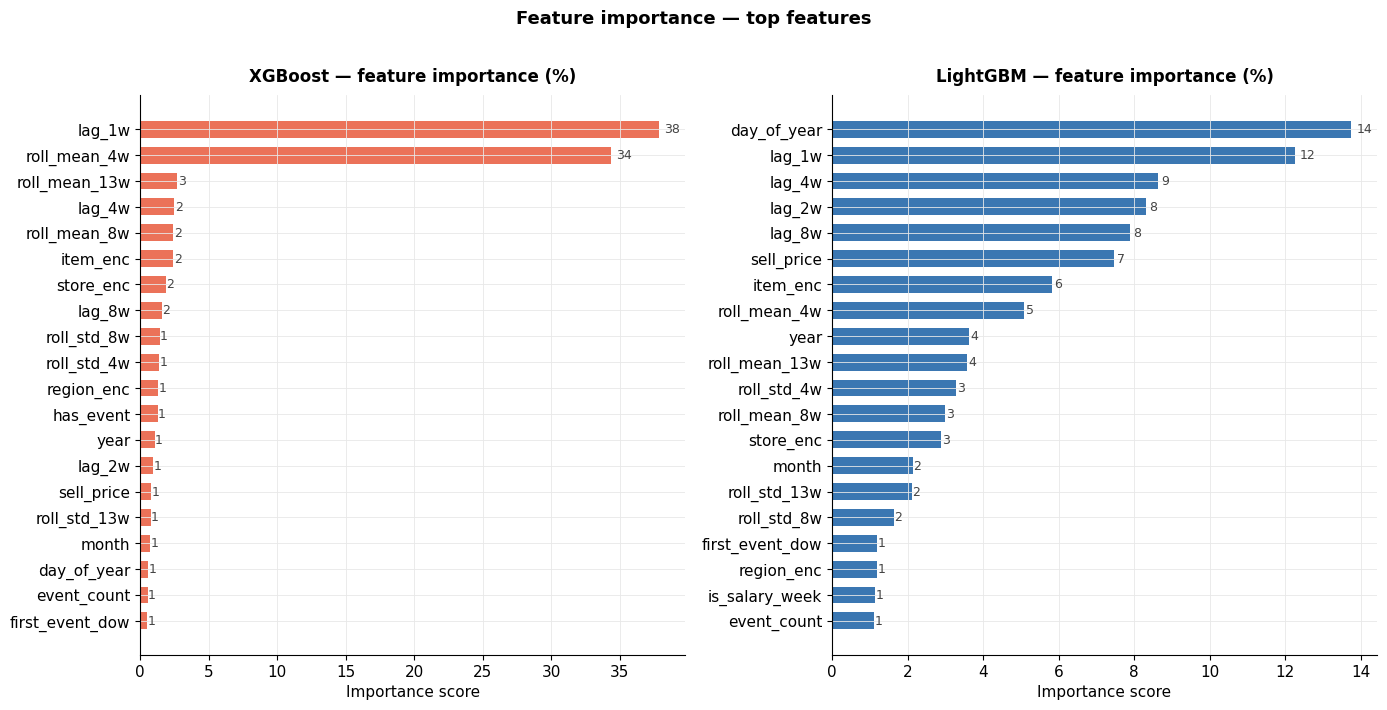

Saved → feature_importance.png

💡 Top feature XGBoost: 'lag_1w' | LightGBM: 'day_of_year'
   Lag features present in top-20: ['lag_2w', 'lag_8w', 'lag_4w', 'lag_1w']
   Rolling features present: ['roll_std_13w', 'roll_std_4w', 'roll_std_8w', 'roll_mean_8w', 'roll_mean_13w', 'roll_mean_4w']

── Per-category breakdown ──
     category  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
HOME_&_GARDEN  562949        7.84           0.24     2.91     2.90      0.37      0.37          0.31          0.29
  SUPERMARKET  770501        9.35           0.22     3.46     3.41      0.37      0.36          0.32          0.31
   ACCESORIES  303820        9.66           0.23     3.54     3.48      0.37      0.36          0.31          0.33


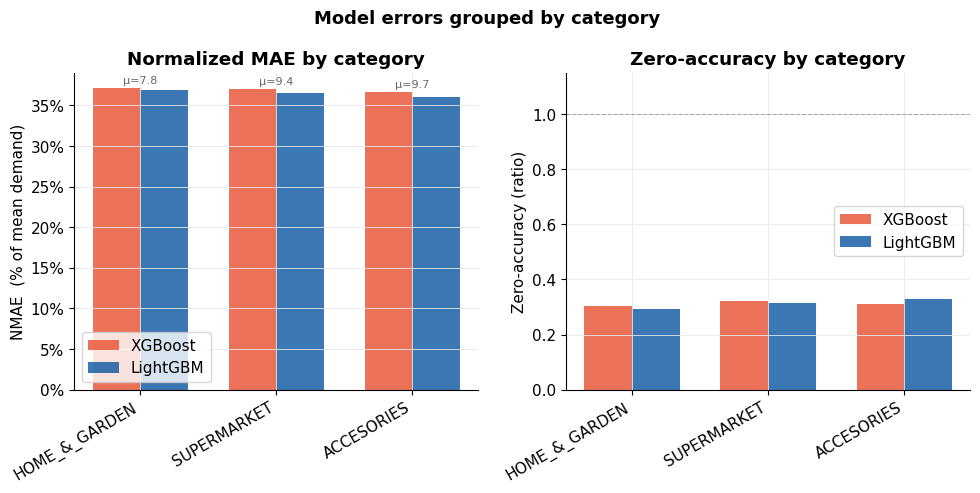

Saved → errors_by_category.png

💡 Hardest group to predict (category): 'HOME_&_GARDEN' (XGB MAE=2.915)
   Easiest group: 'ACCESORIES' (XGB MAE=3.544)

── Per-department breakdown ──
     department  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
  SUPERMARKET_1  116424        6.92           0.26     2.77     2.76      0.40      0.40          0.35          0.32
  SUPERMARKET_2  211273        8.06           0.22     3.13     3.10      0.39      0.38          0.33          0.30
HOME_&_GARDEN_2  277504        6.48           0.25     2.52     2.52      0.39      0.39          0.33          0.30
   ACCESORIES_2   80077        8.59           0.26     3.29     3.24      0.38      0.38          0.31          0.32
   ACCESORIES_1  223743       10.05           0.22     3.64     3.57      0.36      0.36          0.31          0.33
HOME_&_GARDEN_1  285445        9.17           0.22     3.30     3.27      0.36      0.36          0.28          0.28

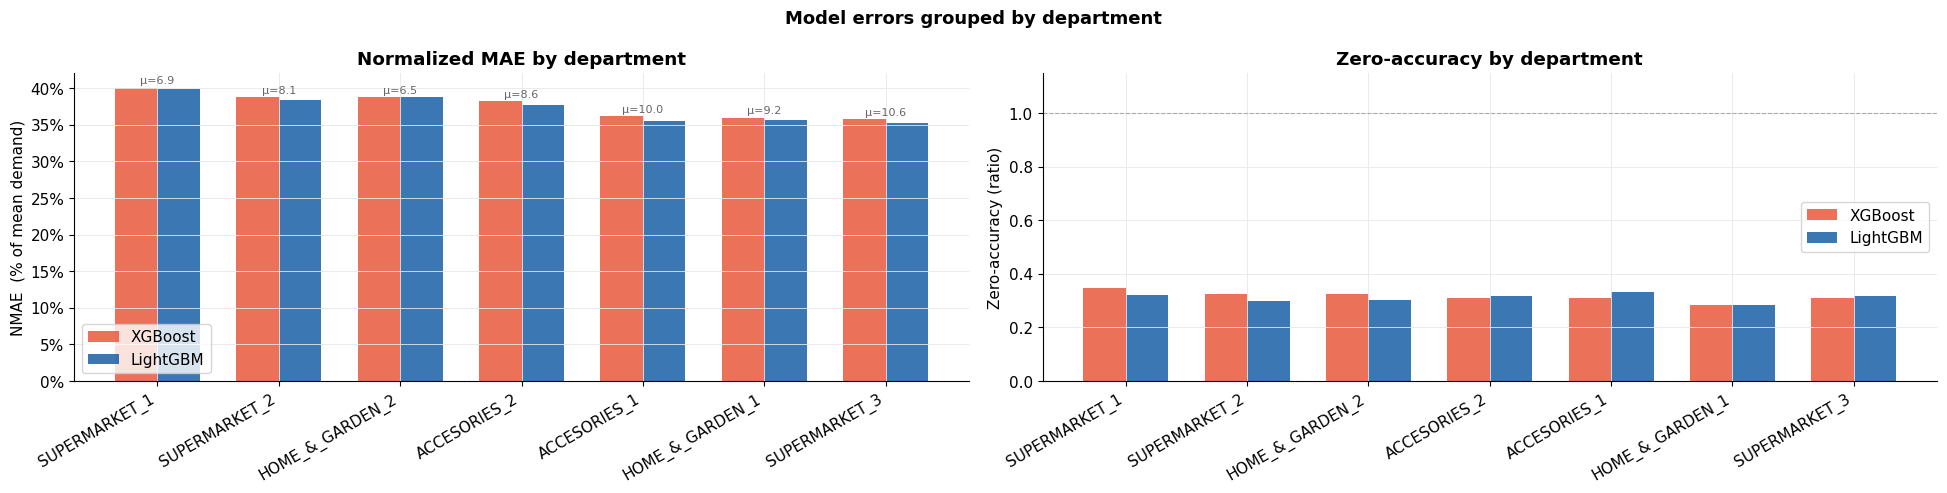

Saved → errors_by_department.png

💡 Hardest group to predict (department): 'SUPERMARKET_1' (XGB MAE=2.775)
   Easiest group: 'SUPERMARKET_3' (XGB MAE=3.802)

── Per-store breakdown ──
            store  n_rows  mean_sales  zero_fraction  xgb_mae  lgb_mae  xgb_nmae  lgb_nmae  xgb_zero_acc  lgb_zero_acc
         Brooklyn  162926        6.81           0.26     2.69     2.67      0.40      0.39          0.35          0.35
        South_End  164461        7.74           0.25     2.97     2.93      0.38      0.38          0.30          0.29
    Queen_Village  164509        7.77           0.26     2.97     2.92      0.38      0.38          0.33          0.32
         Back_Bay  161228        9.07           0.25     3.44     3.39      0.38      0.37          0.32          0.31
          Roxbury  164453        8.35           0.23     3.16     3.12      0.38      0.37          0.31          0.31
Greenwich_Village  164366        8.17           0.22     3.05     3.03      0.37      0.37          0.

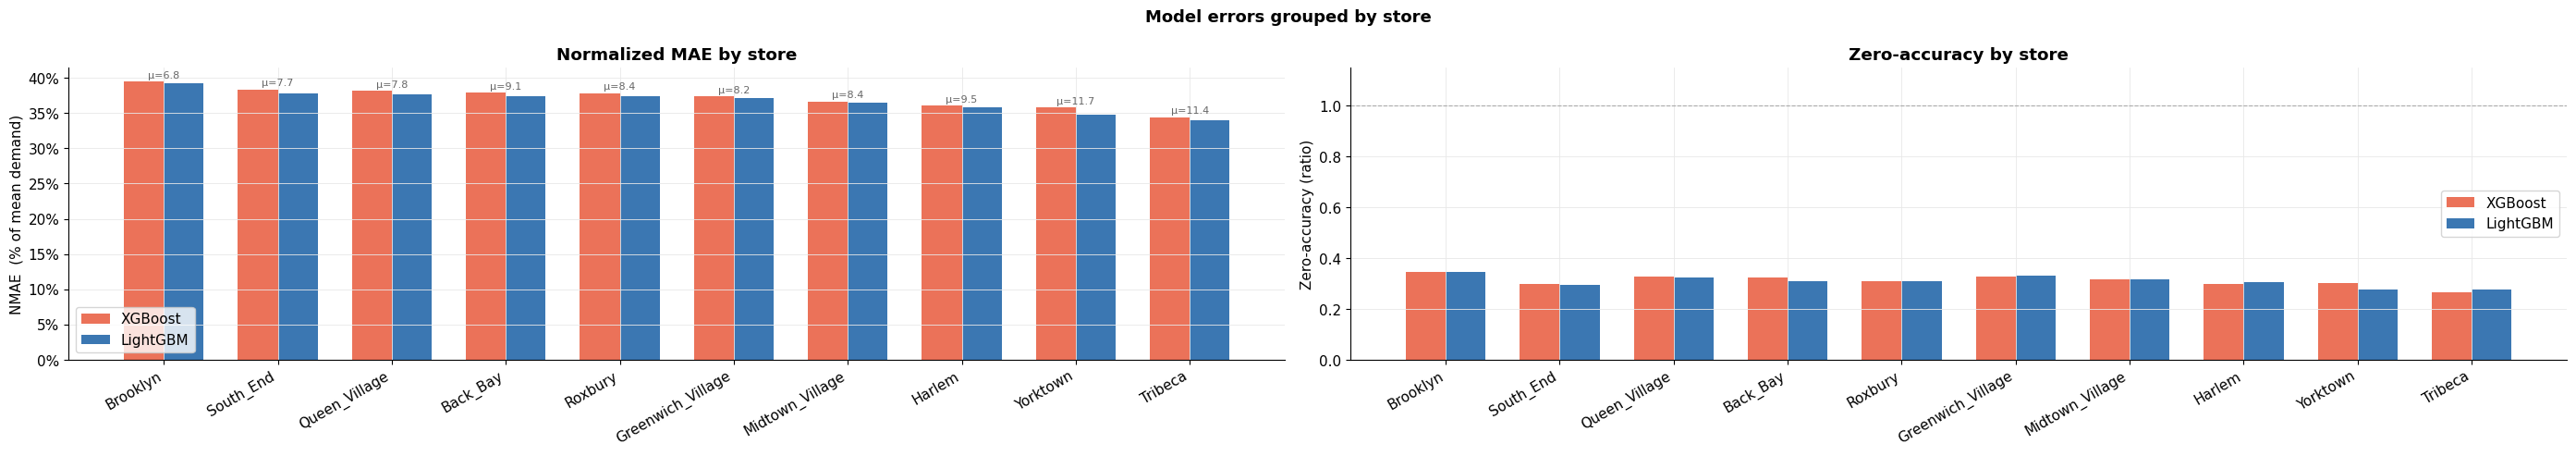

Saved → errors_by_store.png

💡 Hardest group to predict (store): 'Brooklyn' (XGB MAE=2.689)
   Easiest group: 'Tribeca' (XGB MAE=3.922)


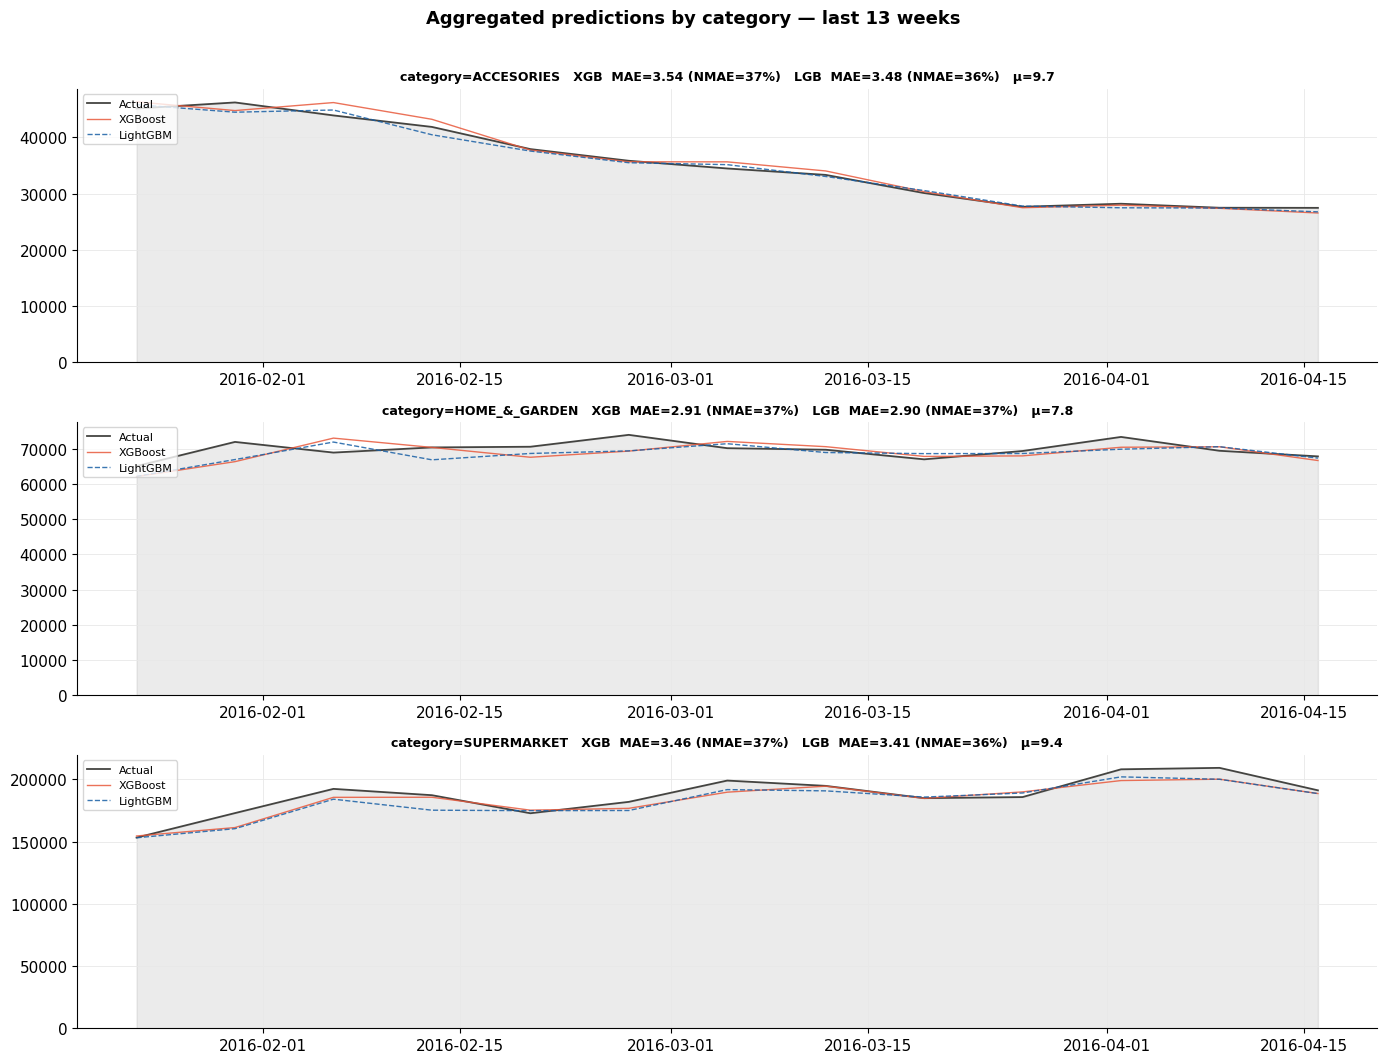

Saved → grid_by_category.png


In [ ]:
raw = df_dsMarket_weekly.sort_values(["yearweek", "store", "item"]).reset_index(drop=True)

# Alineación de índices: el modelo se entrenó en un conjunto reducido por las filas perdidas al crear lags/rolls

n_total   = len(results["X_test"]) + int(len(results["X_test"]) / (1- TRAIN_RATIO) * TRAIN_RATIO)
lag_drop  = len(raw) - n_total          # rows lost to lag NaN warmup
split_idx = lag_drop + int(n_total * TRAIN_RATIO)
test_meta_weekly = raw.iloc[split_idx:].reset_index(drop=True)
 
# ── 1. Feature importance ─────────────────────────────────────────────────
plot_feature_importance(results["xgb"], results["lgb"], results["X_test"], top_n=20)

# ── 2. Per-group errors ───────────────────────────────────────────────────
for grp in ["category", "department", "store"]:
    plot_group_errors(results, test_meta = test_meta_weekly, group_col=grp)

# ── 3. Aggregated grid by category ───────────────────────────────────────
week_plot_group_predictions_grid(results, test_meta_weekly, group_col="category", last_n_weeks=13)

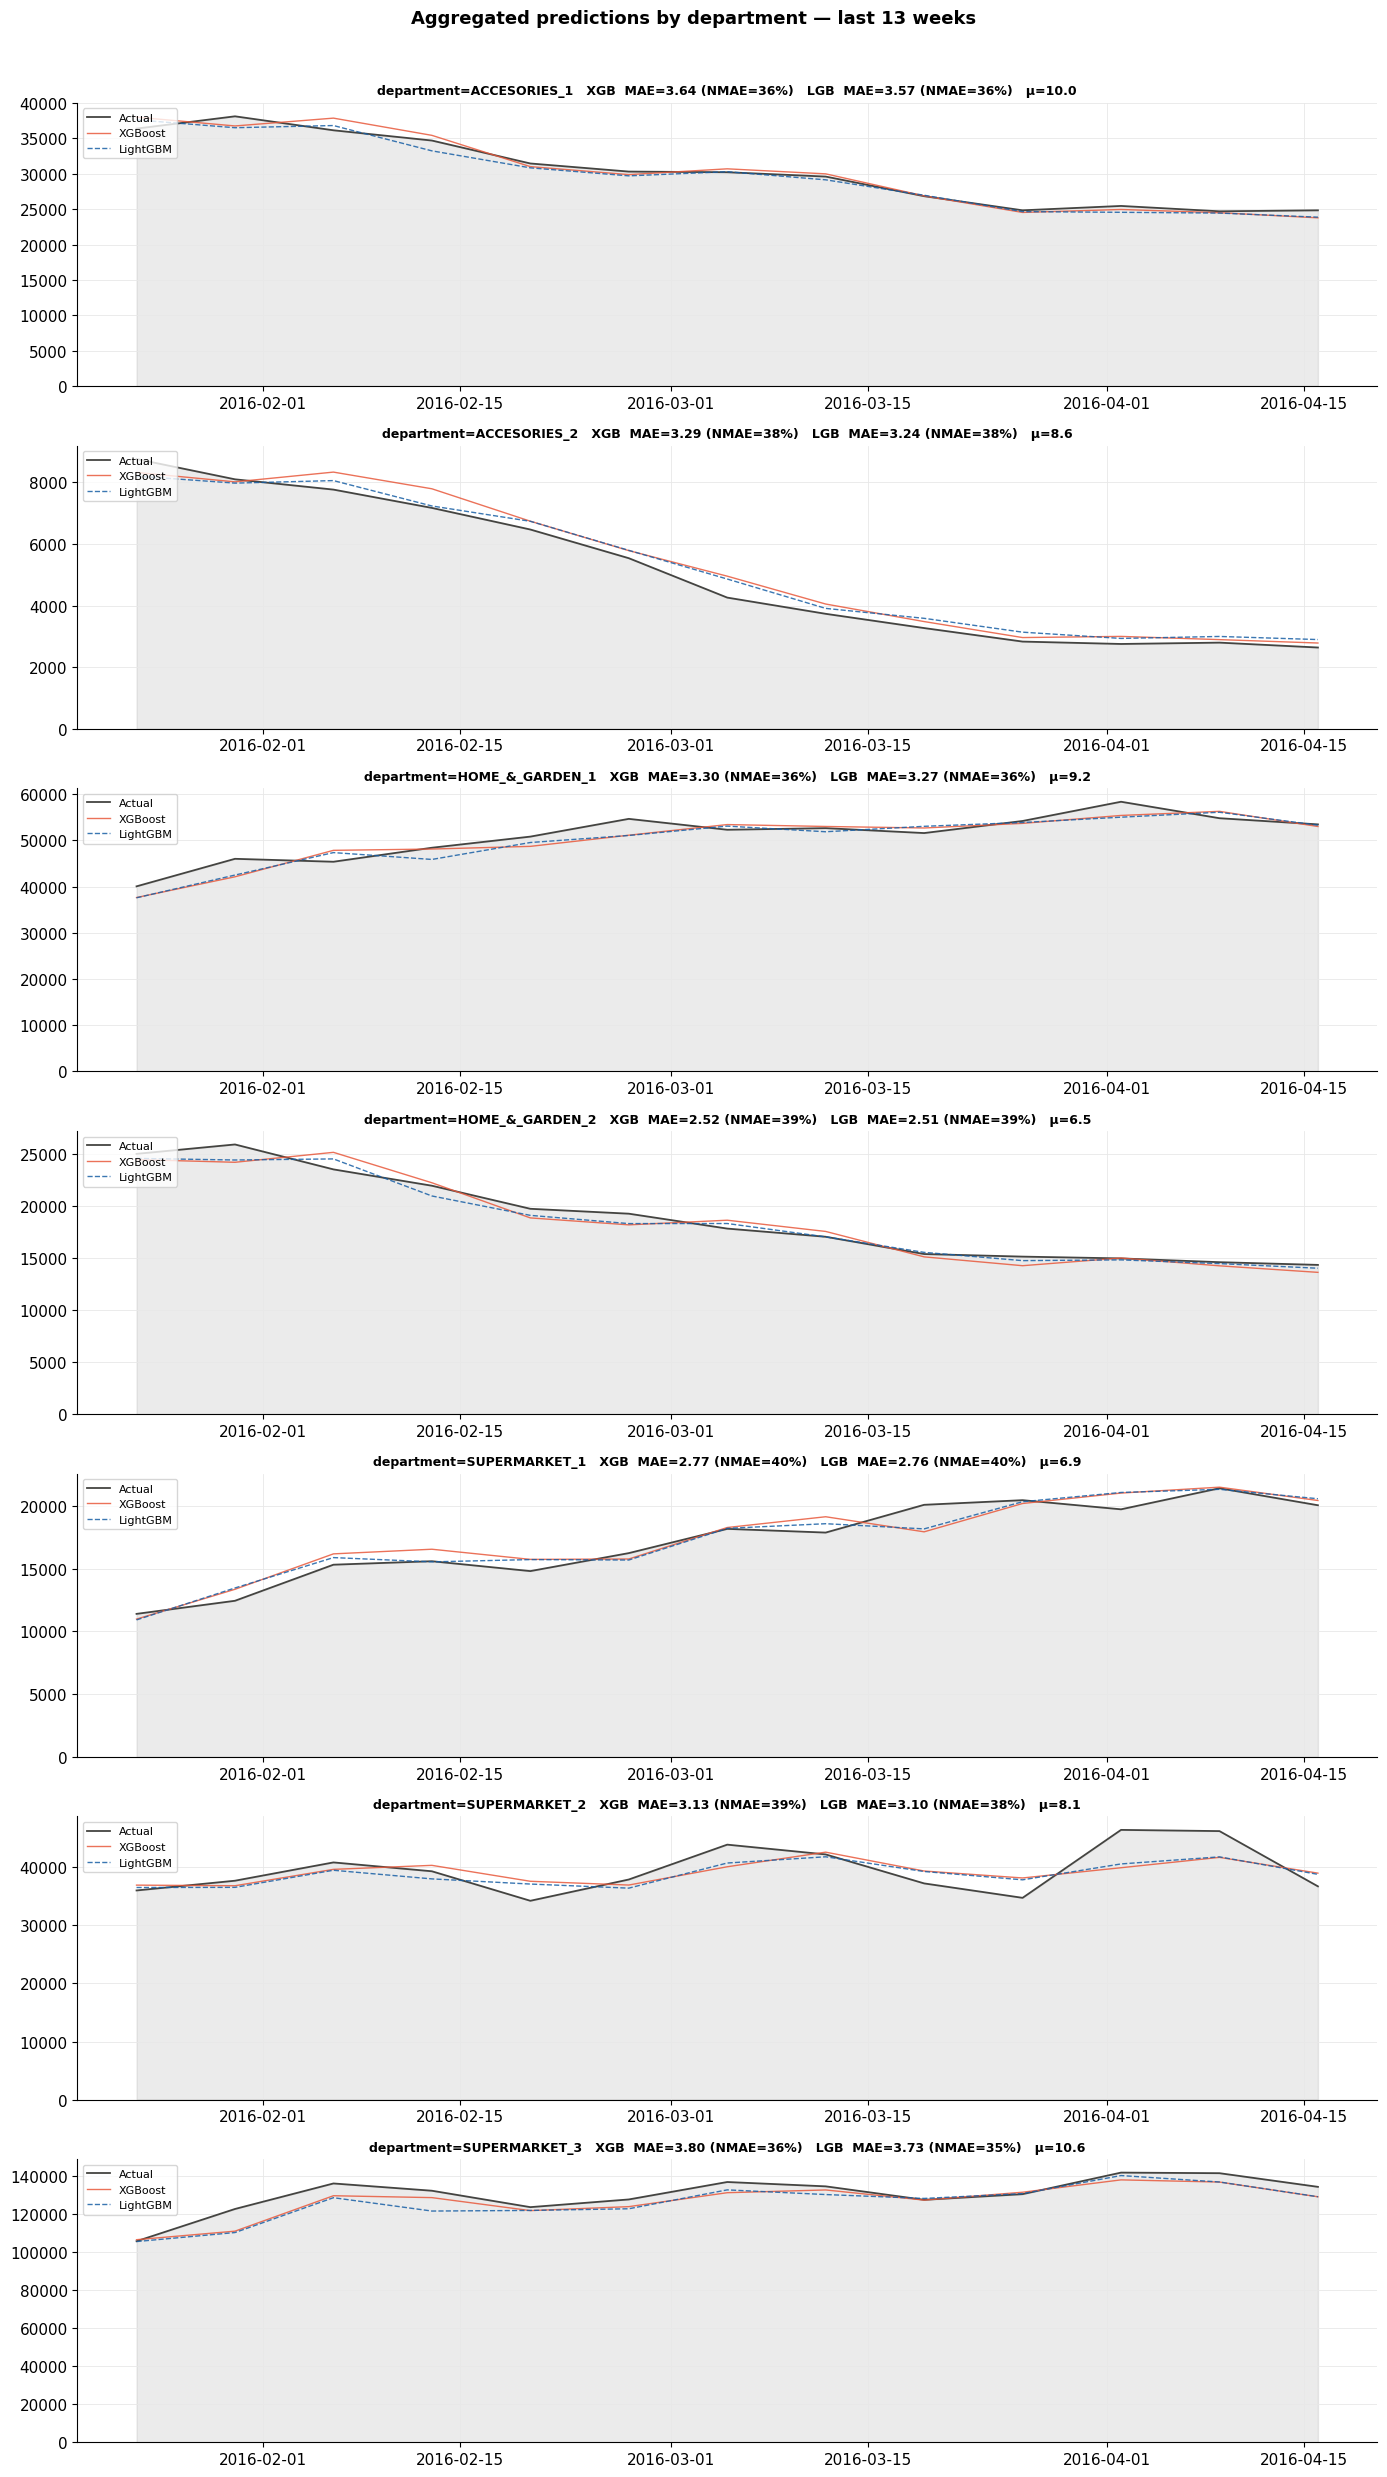

Saved → grid_by_department.png


In [72]:
week_plot_group_predictions_grid(results, test_meta_weekly, group_col="department", last_n_weeks=13)

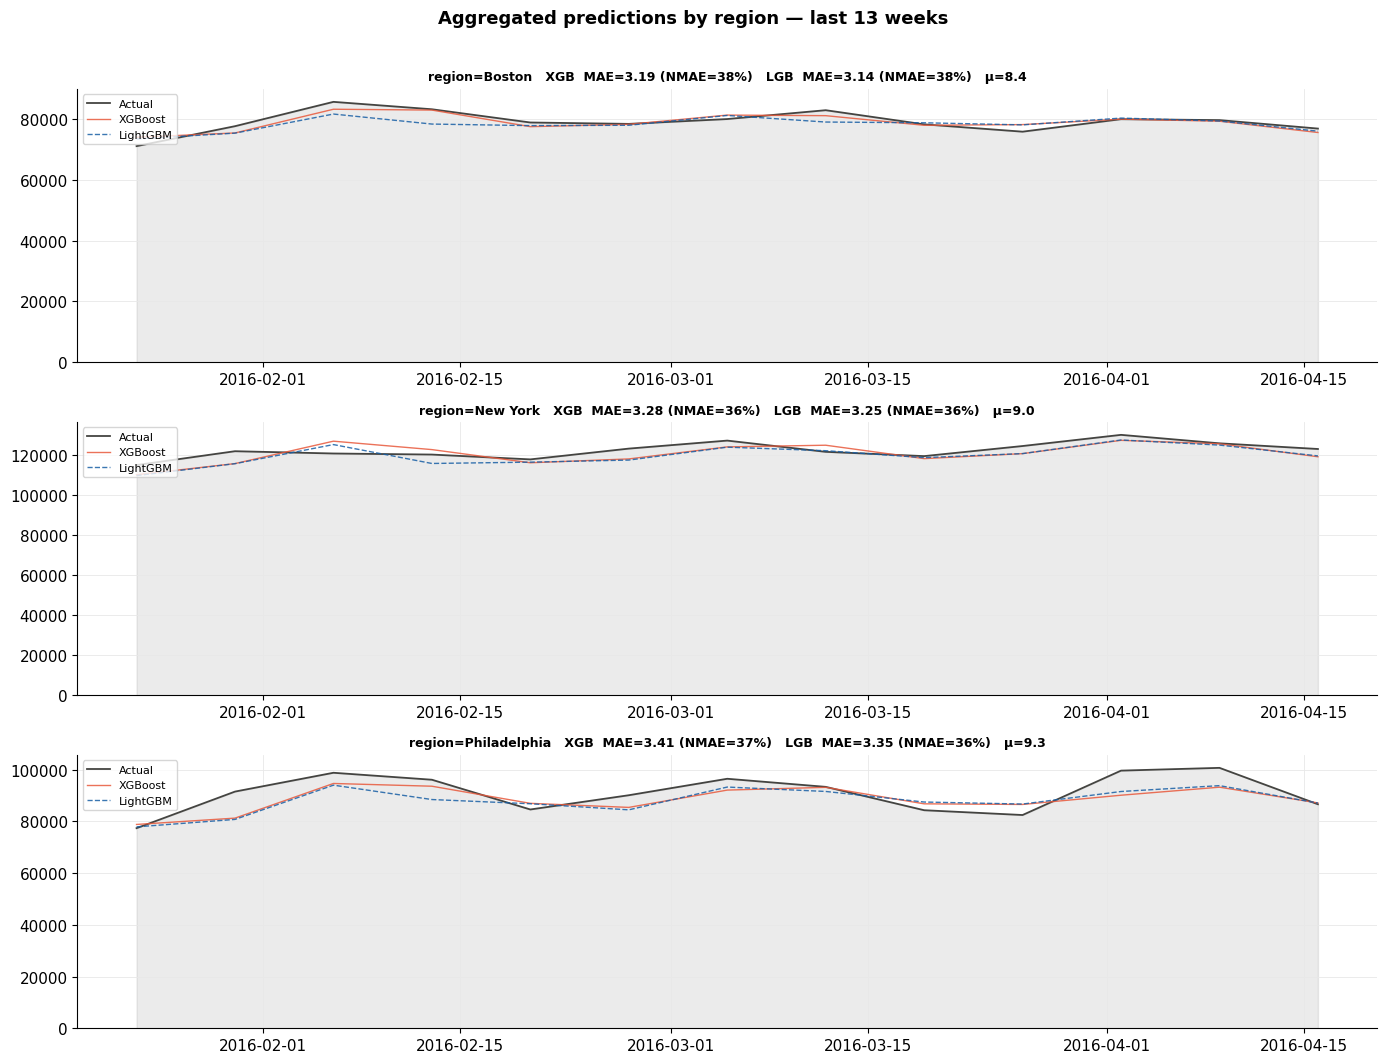

Saved → grid_by_region.png


In [73]:
week_plot_group_predictions_grid(results, test_meta_weekly, group_col="region", last_n_weeks=13)

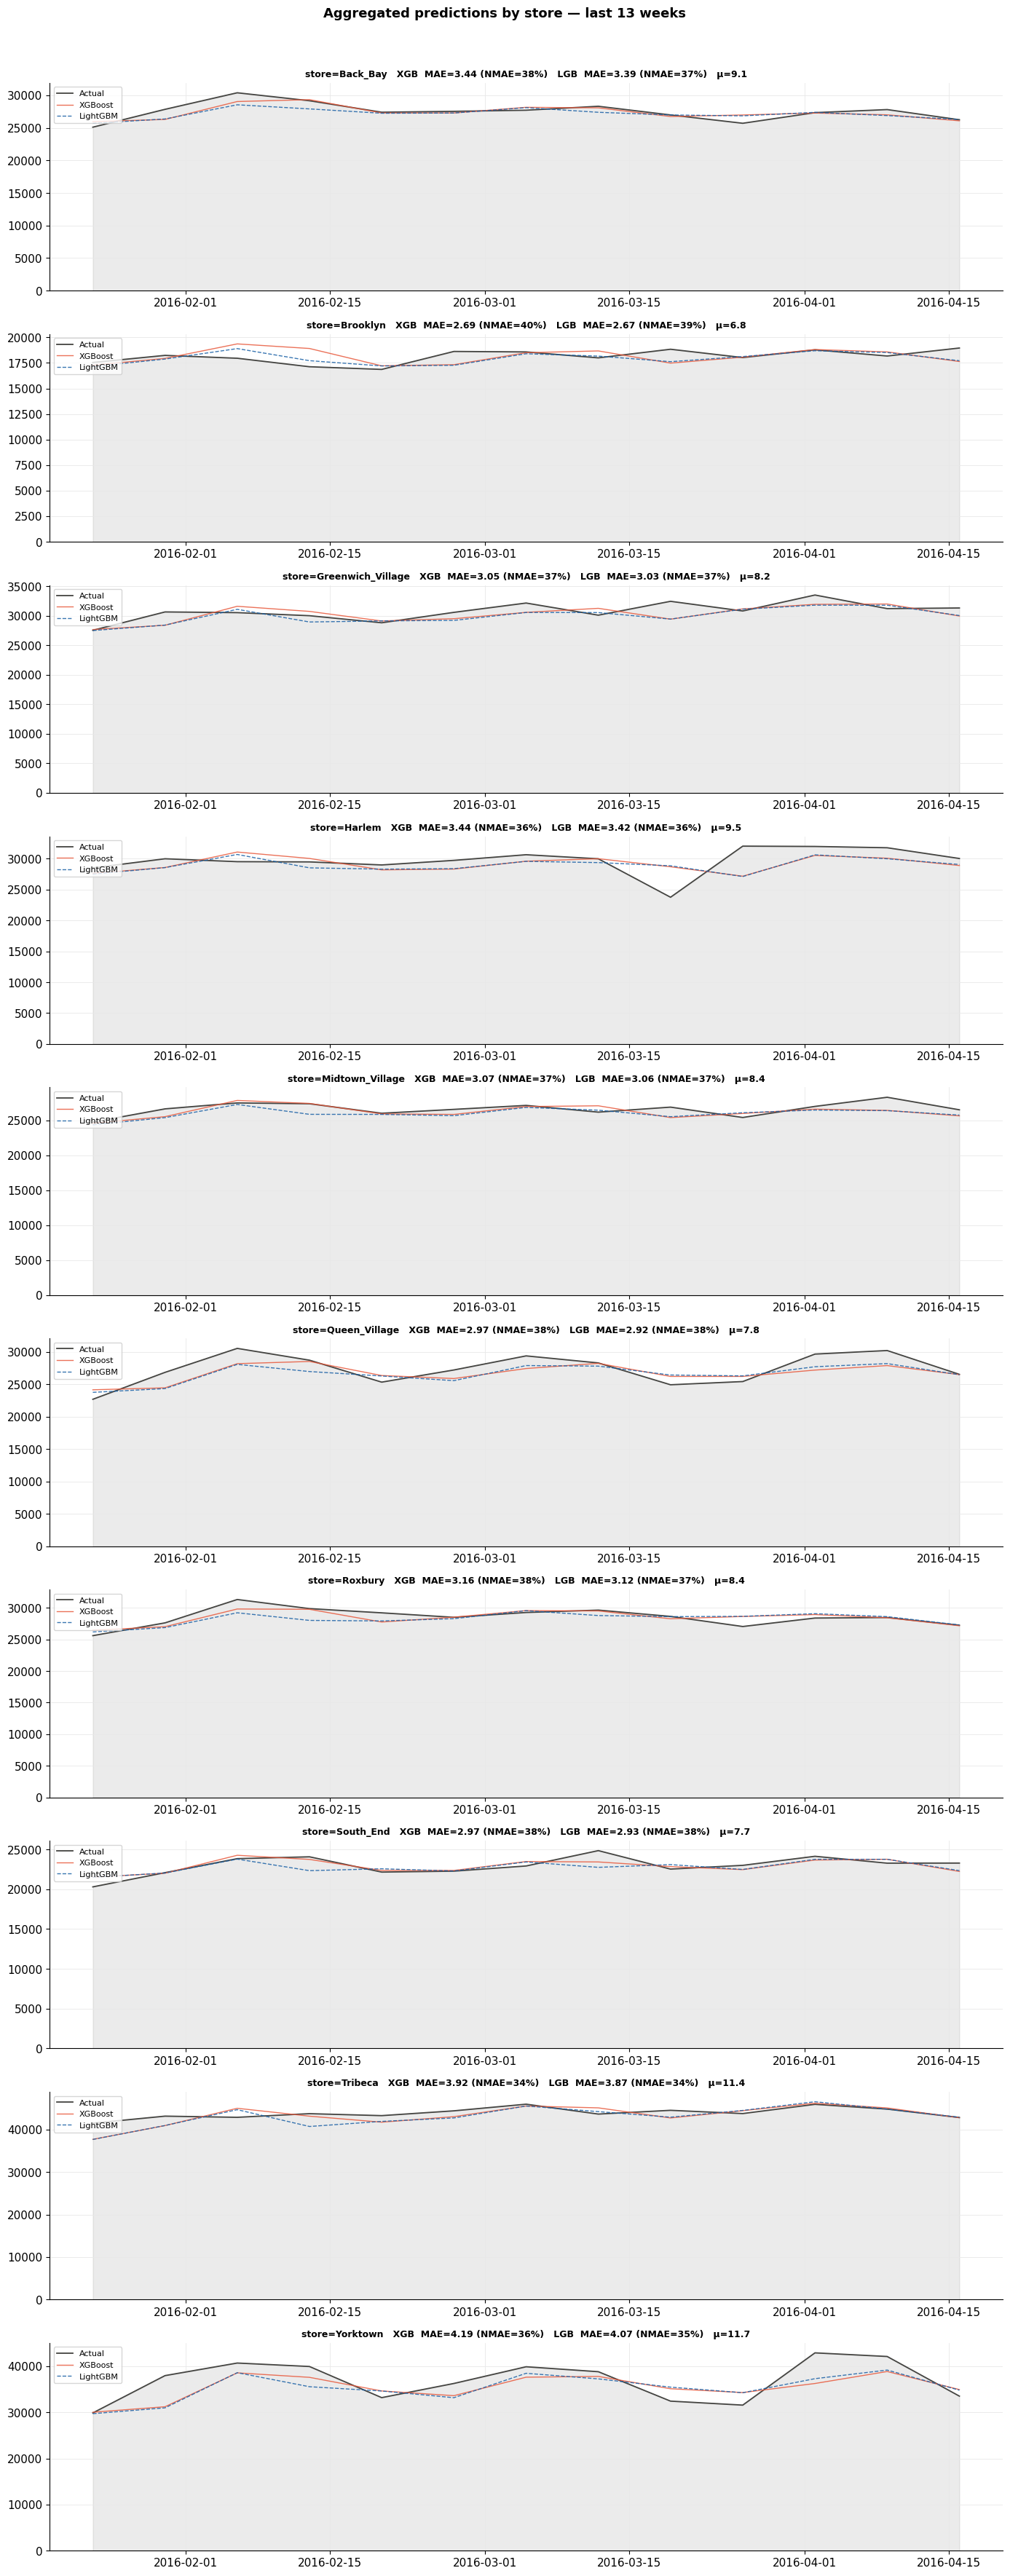

Saved → grid_by_store.png


In [74]:
week_plot_group_predictions_grid(results, test_meta_weekly, group_col="store", last_n_weeks=13)

## 7. Predicciones para las siguientes 4 semanas (201617-201620)

### 7.1. Predicción de las 4 semanas siguientes al dataset

In [ ]:
def predict_future_weeks(
    df_history,        # df preparado con features hasta la última semana comlpeta
    xgb_model,
    lgb_model,
    best_w,
    encoder,
    n_weeks=4
):
    """
    Iteratively predict n_weeks into the future.
    Each predicted week becomes part of history for the next one.
    """
    last_complete_week = sorted(df_history[YEARWEEK_COL].unique())[-1] 
    history = df_history[df_history[YEARWEEK_COL] <= last_complete_week].copy()

    all_forecasts = []
    future_weeks  = generate_future_yearweeks(last_complete_week, n_weeks)

    GROUP_COLS_ENC = [col + "_enc" for col in GROUP_COLS]

    for future_yw in future_weeks:
        # Build a skeleton row for every store × item combination
        groups = history[GROUP_COLS_ENC].drop_duplicates()
        future_rows = groups.copy()
        future_rows[YEARWEEK_COL] = future_yw

        last_known = (
            history.sort_values(YEARWEEK_COL)
                   .groupby(GROUP_COLS_ENC)
                   .last()
                   .reset_index()
        )

        keep_cols =(
            GROUP_COLS + GROUP_COLS_ENC + ["category", "department", "region", "first_event","category_enc", "department_enc", "region_enc", "sell_price", "first_event_enc", "first_event_dow",
                           "event_on_weekend", "event_count", "ramadan_count"]
        )

        last_known = last_known[keep_cols]
        future_rows = future_rows.merge(last_known, on=GROUP_COLS_ENC, how="left")

        # Append to history so lag/rolling functions see the right context
        combined = pd.concat([history, future_rows], ignore_index=True)
        combined = combined.sort_values([YEARWEEK_COL] + GROUP_COLS_ENC).reset_index(drop=True)

        # Recompute date + event + lag + rolling features on the extended df
        combined = add_weekly_date_features(combined)
        combined = clean_event_columns(combined)
               
        combined = add_weekly_lag_features(combined, GROUP_COLS=GROUP_COLS_ENC)
        combined = add_weekly_rolling_features(combined, GROUP_COLS=GROUP_COLS_ENC)

        # Slice only the future week rows
        week_features = combined[combined[YEARWEEK_COL] == future_yw].copy()
        week_features = week_features.drop(columns=[YEARWEEK_COL])
        X_future, _ = split_X_y(week_features)   # no y available yet
        

        # LightGBM can use native categoricals — re-cast them
        cat_features = [c for c in CAT_COLS if c in X_future.columns]
        X_future_lgb = X_future.copy()
        
        for col in cat_features:
            X_future_lgb[col] = X_future_lgb[col].astype("category")

        # Predict and blend
        xgb_p = xgb_model.predict(X_future)
        lgb_p = lgb_model.predict(X_future_lgb)
        preds = best_w * xgb_p + (1 - best_w) * lgb_p
        preds = np.maximum(preds, 0)             # no negative sales
        preds = np.rint(preds).astype(int)  # round to whole units

        # Store results and add predicted sales back into history
        week_features[TARGET] = preds
        week_features[YEARWEEK_COL] = future_yw
        all_forecasts.append(week_features)

        history = pd.concat([history, week_features], ignore_index=True)
        print(f"Predicted week {future_yw}")

    forecast_df = pd.concat(all_forecasts, ignore_index=True)
    forecast_df["is_forecast"] = 1
    forecast_df["revenue_forecast"] = forecast_df[TARGET] * forecast_df["sell_price"]
    return forecast_df


def generate_future_yearweeks(last_yw: int, n: int) -> list[int]:
    """Increment YYYYWW correctly, handling week 52/53 → next year."""
    results = []
    yw = last_yw
    for _ in range(n):
        year, week = yw // 100, yw % 100
        # Check max weeks in this ISO year
        max_week = pd.Timestamp(year, 12, 28).isocalendar().week
        if week >= max_week:
            yw = (year + 1) * 100 + 1
        else:
            yw = year * 100 + (week + 1)
        results.append(yw)
    return results

In [77]:
forecast_df = predict_future_weeks(
    df_history=df_processed,  # full history after feature engineering
    xgb_model=results["xgb"],
    lgb_model=results["lgb"],
    best_w=best_w,
    encoder=encoder
)

Parsed yearweek → day_of_year, year, month, quarter, is_month_start. 
Event columns cleaned. Weeks with ≥1 event: 824,556 / 6,477,866  | Ramadan weeks: 604,854
Added lag features: ['lag_1w', 'lag_2w', 'lag_4w', 'lag_8w']
Added rolling mean/std for windows: [4, 8, 13] weeks
Predicted week 201617
Parsed yearweek → day_of_year, year, month, quarter, is_month_start. 
Event columns cleaned. Weeks with ≥1 event: 824,556 / 6,508,356  | Ramadan weeks: 604,854
Added lag features: ['lag_1w', 'lag_2w', 'lag_4w', 'lag_8w']
Added rolling mean/std for windows: [4, 8, 13] weeks
Predicted week 201618
Parsed yearweek → day_of_year, year, month, quarter, is_month_start. 
Event columns cleaned. Weeks with ≥1 event: 824,556 / 6,538,846  | Ramadan weeks: 604,854
Added lag features: ['lag_1w', 'lag_2w', 'lag_4w', 'lag_8w']
Added rolling mean/std for windows: [4, 8, 13] weeks
Predicted week 201619
Parsed yearweek → day_of_year, year, month, quarter, is_month_start. 
Event columns cleaned. Weeks with ≥1 event

In [79]:
forecast_df

,item,store,category,department,region,sales,event_count,ramadan_count,first_event,first_event_dow,event_on_weekend,sell_price,year,month,quarter,is_month_start,is_salary_week,day_of_year,has_event,item_enc,store_enc,category_enc,department_enc,region_enc,first_event_enc,lag_1w,lag_2w,lag_4w,lag_8w,roll_mean_4w,roll_std_4w,roll_mean_8w,roll_std_8w,roll_mean_13w,roll_std_13w,yearweek,is_forecast,revenue_forecast
0,ACCESORIES_1_001,Back_Bay,ACCESORIES,ACCESORIES_1,Boston,2,0,0,NoEvent,-1,0,10.99,2016,4,2,0,0,114,0,0,0,0,0,0,4,3.00,2.00,3.00,3.00,2.50,0.58,2.88,0.64,3.31,1.03,201617,1,21.97
1,ACCESORIES_1_002,Back_Bay,ACCESORIES,ACCESORIES_1,Boston,1,0,0,NoEvent,-1,0,5.28,2016,4,2,0,0,114,0,1,0,0,0,0,4,1.00,0.00,1.00,0.00,0.75,0.50,0.75,0.71,0.54,0.66,201617,1,5.28
2,ACCESORIES_1_003,Back_Bay,ACCESORIES,ACCESORIES_1,Boston,2,0,0,NoEvent,-1,0,3.95,2016,4,2,0,0,114,0,2,0,0,0,0,4,1.00,3.00,3.00,0.00,2.25,0.96,1.75,1.16,1.54,1.05,201617,1,7.90
3,ACCESORIES_1_004,Back_Bay,ACCESORIES,ACCESORIES_1,Boston,3,0,0,NoEvent,-1,0,6.17,2016,4,2,0,0,114,0,3,0,0,0,0,4,0.00,7.00,6.00,0.00,5.50,3.87,3.75,3.65,4.08,2.96,201617,1,18.51
4,ACCESORIES_1_005,Back_Bay,ACCESORIES,ACCESORIES_1,Boston,3,0,0,NoEvent,-1,0,3.63,2016,4,2,0,0,114,0,4,0,0,0,0,4,2.00,5.00,2.00,1.00,3.50,1.73,3.50,1.93,3.46,1.56,201617,1,10.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121955,SUPERMARKET_3_823,Yorktown,SUPERMARKET,SUPERMARKET_3,Philadelphia,4,0,0,NoEvent,-1,0,3.58,2016,5,2,0,1,135,0,3044,9,2,6,2,4,4.00,3.00,2.00,0.00,3.00,0.82,1.50,1.69,2.46,2.54,201620,1,14.30
121956,SUPERMARKET_3_824,Yorktown,SUPERMARKET,SUPERMARKET_3,Philadelphia,4,0,0,NoEvent,-1,0,2.98,2016,5,2,0,1,135,0,3045,9,2,6,2,4,4.00,4.00,4.00,0.00,4.00,0.00,3.62,2.20,2.23,2.49,201620,1,11.90
121957,SUPERMARKET_3_825,Yorktown,SUPERMARKET,SUPERMARKET_3,Philadelphia,12,0,0,NoEvent,-1,0,4.78,2016,5,2,0,1,135,0,3046,9,2,6,2,4,13.00,12.00,13.00,9.00,12.25,0.96,12.38,4.78,11.38,4.66,201620,1,57.31
121958,SUPERMARKET_3_826,Yorktown,SUPERMARKET,SUPERMARKET_3,Philadelphia,10,0,0,NoEvent,-1,0,1.54,2016,5,2,0,1,135,0,3047,9,2,6,2,4,10.00,9.00,14.00,0.00,10.75,2.22,7.38,4.93,6.62,4.57,201620,1,15.36


### 7.2. Adición de la medición WMAPE por categoría

In [ ]:
forecast_df = forecast_df.merge(
    category_metrics[["category", "WMAPE"]],
    on="category",
    how="left"
)

forecast_df["WMAPE"] = (
    forecast_df["WMAPE"]
        .clip(0, 0.80)
)

forecast_df["forecast_quality_pct"] = (
    (1 - forecast_df["WMAPE"]) * 100
).round(1)


### 7.3. Exportación de las predicciones con varias mediciones de calidad de predicción así como comparadores de las predicciones con periodos anterirores

En vistas a la presentación, se decide limitar la información mostrada en PowerBI, dado que hemos creado muchas columnas y alguna información puede resultar confusa. 
En lo referido a los resultados de las predicciones, son ligeramente decrecientes (36.4% del total bajan más del 5%, con 32.1% estable entre +5% y -5%) dada la clara tendencia en descenso en categorías como accesories y home_&_garden_2.

In [81]:
def export_for_powerbi(history_df, forecast_df, segment_mape: dict):
    """
    Combine actuals + forecast into one long-format CSV.
    Decode categoricals back to readable labels.
    """
    # Tag actuals
    actuals = history_df.copy()
    actuals["is_forecast"]       = False
    actuals["revenue_forecast"]  = actuals["sales"] * actuals["sell_price"]
    actuals["pred_lower"]        = np.nan
    actuals["pred_upper"]        = np.nan

    # Add prediction intervals to forecast (±1 std of recent errors as proxy)
    # A simple approach: use rolling std of residuals from test set

    # Compute per-segment MAPE from test set, use as dynamic CI width
    forecast_df["mape_for_segment"] = forecast_df["category"].astype(str).map(segment_mape).fillna(0.15)
    forecast_df["mape_for_segment"] = (
        forecast_df["mape_for_segment"]
            .clip(0.10, 0.40)
    )
    forecast_df["pred_lower"] = forecast_df[TARGET] * (1 - forecast_df["mape_for_segment"])
    forecast_df["pred_upper"] = forecast_df[TARGET] * (1 + forecast_df["mape_for_segment"])
    # forecast_df["pred_lower"] = forecast_df[TARGET] * 0.85   # replace with real CI
    # forecast_df["pred_upper"] = forecast_df[TARGET] * 1.15

    combined = pd.concat([actuals, forecast_df], ignore_index=True)

    # # Decode categoricals so Power BI labels are readable
    # cat_cols_present = [c for c in CAT_COLS if c in combined.columns]
    # combined[cat_cols_present] = encoder.inverse_transform(combined[cat_cols_present])
    yw = combined[YEARWEEK_COL].astype(str).str.zfill(6)
    year = yw.str[:4].astype(int)
    week = yw.str[4:].astype(int)

    # Fix invalid week 00 → treat as week 1 (or shift to last week prev year if you prefer)
    week = week.replace(0, 1)

    # Build a base date: Jan 1 of each year
    base_date = pd.to_datetime(year.astype(str) + "-01-01")

    # Since your weeks start on Saturday:
    # We shift to the first Saturday of the year, then add weeks
    first_saturday = base_date + pd.to_timedelta((5 - base_date.dt.weekday) % 7, unit="D")

    week_start = first_saturday + pd.to_timedelta((week - 1) * 7, unit="D")



    # Derive a real date column — Power BI date slicers need this
    combined["week_start_date"] = week_start
    combined["week_start_date"] = pd.to_datetime(combined["week_start_date"])

    # Enforce dtypes explicitly before writing
    # Parquet is schema-strict: mixed int/float columns cause silent cast issues
    combined[TARGET]            = combined[TARGET].round().astype(int)
    combined["revenue_forecast"] = combined["revenue_forecast"].round(2).astype("float64")
    combined["sell_price"]       = combined["sell_price"].round(2).astype("float64")
    combined["pred_lower"]       = combined["pred_lower"].round(2).astype("float64")
    combined["pred_upper"]       = combined["pred_upper"].round(2).astype("float64")
    combined["is_forecast"]      = combined["is_forecast"].astype(bool)

    cols = [
        "week_start_date", YEARWEEK_COL, "store", "item",
        "category", "department", "region",
        TARGET, "revenue_forecast",
        "sell_price", "is_forecast",
        "pred_lower", "pred_upper", "WMAPE", "forecast_quality_pct"
    ]

    out = combined[[c for c in cols if c in combined.columns]]

    out = out.sort_values(["week_start_date","store", "item"]).reset_index(drop=True)
    out["week_index"] = np.arange(len(out))  # add a simple index for Power BI sorting if needed

    out = out.sort_values(
        ["store", "item", "week_start_date"]
    )
    #------- Features for Power BI visualizations -------
    out["period_type"] = np.where(
        out["is_forecast"],
        "Prediccion",
        "Historico"
    )

    out["revenue_4w"] = (
        out.groupby(["store", "item"])["revenue_forecast"]
                .transform(lambda s: s.rolling(4).sum())
    )



    out["revenue_prev_4w"] = (
        out.groupby(["store", "item"])["revenue_4w"]
                .shift(4)
    )

    out["revenue_vs_prev4w"] = (
        out["revenue_4w"] -
        out["revenue_prev_4w"]
    )

    out["revenue_vs_prev4w_pct"] = (
        out["revenue_vs_prev4w"] /
        out["revenue_prev_4w"]
    ) * 100
    

    out["revenue_last_year"] = (
        out.groupby(["store", "item"])["revenue_forecast"]
        .transform(
            lambda s: s.shift(52).rolling(3, center=True, min_periods=1).mean()
        )
    )

    out["revenue_yoy"] = (
        out["revenue_forecast"] -
        out["revenue_last_year"]
    )

    out["revenue_yoy_pct"] = (
        out["revenue_yoy"] /
        out["revenue_last_year"]
    ) * 100

    out["trend_label"] = np.select(
        [
            out["revenue_yoy_pct"] > 5,
            out["revenue_yoy_pct"] < -5
        ],
        [
            "Growing",
            "Declining"
        ],
        default="Stable"
    )

    out["sales_prev_4w"] = (
        out.groupby(["store", "item"])["sales"]
                .transform(lambda s: s.shift(1).rolling(4).sum())
    )
    out["sales_yoy"] = (
        out.groupby(["store", "item"])["sales"]
                .diff(52)
    )


    out["yoy_flag"] = np.where(
        out["revenue_last_year"] == 0,
        "no_baseline",
        "ok"
    )

    out.to_parquet(
        "forecast_powerbi.parquet",
        engine="pyarrow",
        compression="snappy",    # good balance of speed vs size; Power BI reads it fine
        index=False,
    )
    print(f"Exported {len(out):,} rows → forecast_powerbi.parquet")
    return out


# def yearweek_to_date(yw: int) -> str:
#     year, week = yw // 100, yw % 100
#     return pd.Timestamp.fromisocalendar(year, max(week, 1), 1).strftime("%Y-%m-%d")

In [82]:
forecast_parquet = export_for_powerbi(history_df=df_processed, forecast_df=forecast_df, segment_mape=segment_mape)

Exported 6,569,336 rows → forecast_powerbi.parquet


In [86]:
forecast_parquet.tail(10)

,week_start_date,yearweek,store,item,category,department,region,sales,revenue_forecast,sell_price,is_forecast,pred_lower,pred_upper,WMAPE,forecast_quality_pct,week_index,period_type,revenue_4w,revenue_prev_4w,revenue_vs_prev4w,revenue_vs_prev4w_pct,revenue_last_year,revenue_yoy,revenue_yoy_pct,trend_label,sales_prev_4w,sales_yoy,yoy_flag
6294952,2016-03-12,201611,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,28,33.60,1.20,False,NaN,NaN,NaN,NaN,6294952,Historico,106.80,126.00,-19.20,-15.24,18.40,15.20,82.61,Growing,92.00,16.00,ok
6325431,2016-03-19,201612,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,7,8.40,1.20,False,NaN,NaN,NaN,NaN,6325431,Historico,93.60,124.80,-31.20,-25.00,16.40,-8.00,-48.78,Declining,89.00,-5.00,ok
6355913,2016-03-26,201613,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,24,28.80,1.20,False,NaN,NaN,NaN,NaN,6355913,Historico,99.60,114.00,-14.40,-12.63,23.60,5.20,22.03,Growing,78.00,7.00,ok
6386395,2016-04-02,201614,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,21,25.20,1.20,False,NaN,NaN,NaN,NaN,6386395,Historico,96.00,110.40,-14.40,-13.04,30.00,-4.80,-16.00,Declining,83.00,-9.00,ok
6416885,2016-04-09,201615,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,25,30.00,1.20,False,NaN,NaN,NaN,NaN,6416885,Historico,92.40,106.80,-14.40,-13.48,28.40,1.60,5.63,Growing,80.00,-3.00,ok
6447375,2016-04-16,201616,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,13,15.60,1.20,False,NaN,NaN,NaN,NaN,6447375,Historico,99.60,93.60,6.00,6.41,26.80,-11.20,-41.79,Declining,77.00,0.00,ok
6477865,2016-04-23,201617,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,18,21.60,1.20,True,10.80,25.20,0.35,65.40,6477865,Prediccion,92.40,99.60,-7.20,-7.23,16.00,5.60,35.00,Growing,83.00,-8.00,ok
6508355,2016-04-30,201618,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,19,22.80,1.20,True,11.40,26.60,0.35,65.40,6508355,Prediccion,90.00,96.00,-6.00,-6.25,10.80,12.00,111.11,Growing,77.00,18.00,ok
6538845,2016-05-07,201619,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,21,25.20,1.20,True,12.60,29.40,0.35,65.40,6538845,Prediccion,85.20,92.40,-7.20,-7.79,0.40,24.80,"6,200.00",Growing,75.00,21.00,ok
6569335,2016-05-14,201620,Yorktown,SUPERMARKET_3_827,SUPERMARKET,SUPERMARKET_3,Philadelphia,20,24.00,1.20,True,12.00,28.00,0.35,65.40,6569335,Prediccion,93.60,99.60,-6.00,-6.02,0.00,24.00,inf,Growing,71.00,20.00,no_baseline


In [104]:
pivot_pct = pd.crosstab(
    forecast_parquet["category"],
    forecast_parquet["trend_label"],
    margins=True,
    normalize="index"
) * 100

print(pivot_pct.round(1))

trend_label    Declining  Growing  Stable
category                                 
ACCESORIES         37.00    30.60   32.40
HOME_&_GARDEN      36.20    31.10   32.70
SUPERMARKET        36.30    32.20   31.50
All                36.40    31.50   32.10


In [84]:
forecast_parquet.forecast_quality_pct.mean()

np.float64(62.12489340767462)